#### Done: pmf, cdf, icdf, mean, variance, skewness, mode, param_shape

# Exact

In [ ]:
from typing import Optional, Tuple

import torch
from torch import Tensor
from torch.distributions import constraints
from torch.distributions.distribution import Distribution
from torch.distributions.utils import lazy_property, logits_to_probs, probs_to_logits
from torch.distributions import Normal
from torch.fft import fft, ifft
import math
import torch.nn.functional as F

__all__ = ["PoissonBinomialExact"]

def _clamp_by_zero(x):
    return (x.clamp(min=0) + x - x.clamp(max=0)) / 2

class PoissonBinomialExact(Distribution):
    arg_constraints = {
        "probs": constraints.unit_interval,
        "logits": constraints.real,
    }
    has_enumerate_support = True
    support = constraints.nonnegative_integer

    def __init__(
        self,
        probs: Optional[Tensor] = None,
        logits: Optional[Tensor] = None,
        validate_args: Optional[bool] = True,
    ):
        if (probs is None) == (logits is None):
            raise ValueError("Either `probs` or `logits` must be specified, but not both.")
        if probs is not None:
            if not isinstance(probs, Tensor):
                probs = torch.as_tensor(probs, dtype=torch.float32)
            self.probs = probs
            self.logits = None
        else:
            if not isinstance(logits, Tensor):
                logits = torch.as_tensor(logits, dtype=torch.float32)
            self.logits = logits
            self.probs = logits_to_probs(logits)
        super().__init__(batch_shape=self.probs.shape[:-1], validate_args=False)

    def expand(self, batch_shape, _instance=None):
        new_instance = self._get_checked_instance(PoissonBinomialExact, _instance)
        new_instance.probs = self.probs.expand(batch_shape + self.probs.shape)
        super(PoissonBinomialExact, new_instance).__init__(
            batch_shape=batch_shape,
            validate_args=False,
        )
        new_instance._validate_args = self._validate_args
        return new_instance
    
    def pmf(self, device='cpu'):
        probs = self.probs.to(dtype=torch.float64)
        batch_shape = probs.shape[:-1]
        n = probs.shape[-1]
        N = n + 1       
        j = torch.arange(N, device=device, dtype=torch.float64)
        omega = torch.exp(2j * math.pi * j / N)
        p_i = probs.unsqueeze(-1) 
        term = (1 - p_i) + p_i * omega
        cf = torch.ones(batch_shape + (N,), dtype=torch.complex128, device=device)
        
        for i in range(n):
            cf = cf * ((1 - probs[..., i, None]) + probs[..., i, None] * omega)
        
        pmf = torch.fft.fft(cf, dim=-1).real / N
        pmf = pmf.clamp_(min=0.0)

        return pmf.to(self.probs.dtype)

    def cdf(self, value=None, device='cpu'):
        pmf = self.pmf()
        cdf_full = torch.cumsum(pmf, dim=-1) 
    
        if value is None:
            return cdf_full
        
        value = torch.as_tensor(value, dtype=torch.long, device=pmf.device)
        value = value.clamp_(min=0, max=pmf.shape[-1]-1)

        if len(self.batch_shape) == 0:
            return cdf_full[value]
        else:
            if value.shape[:len(self.batch_shape)] != self.batch_shape:
                raise ValueError(
                    f"Expected value to have batch prefix {self.batch_shape}, "
                    f"got shape {value.shape}"
                )
            indices = value.unsqueeze(-1)
            return cdf_full.gather(-1, indices).squeeze(-1)
    
    def icdf(self, value=None, device='cpu', algo='searchsorted'):
        pmf = self.pmf()
        cdf_full = torch.cumsum(pmf, dim=-1) 
    
        if value is None:
            return cdf_full
        
        value = torch.as_tensor(value, dtype=torch.float32, device=pmf.device)
        value = value.clamp_(min=0.0, max=1.0)
        
        icdf_values = torch.searchsorted(cdf_full, value, right=True)
        return icdf_values
    
    @property
    def mean(self) -> Tensor:
        return self.probs.sum(-1)
    
    @property
    def variance(self) -> Tensor:
        return (self.probs * (1 - self.probs)).sum(-1)

    @property
    def skewness(self) -> Tensor:
        p = self.probs
        term = p * (1 - p) * (1 - 2 * p)
        return term.sum(-1) / self.variance.clamp(min=1e-8).pow(1.5)
    
    @property
    def mode(self) -> Tensor:
        return self.pmf().argmax(dim=-1)
    
    @property
    def param_shape(self) -> torch.Size:
        return self._param.size()

c:\Users\matth\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


## Tests

In [57]:
import torch

probs = torch.tensor([[0.1, 0.2, 0.7],
                      [0.3, 0.4, 0.6]], dtype=torch.float32)

dist = PoissonBinomialExact(probs=probs)

print("=== Basic checks ===")
print("batch_shape   :", dist.batch_shape)
print("mean          :", dist.mean)
print("variance      :", dist.variance)
print("skewness      :", dist.skewness)

print("\n=== Expand checks ===")
exp = dist.expand((5,))
print("expanded batch :", exp.batch_shape)      # should be [5, 2]
print("expanded probs :", exp.probs.shape)      # [5, 2, 3]
print("expanded mean  :", exp.mean.shape)       # [5, 2]

print("\n=== Things that will likely fail ===")
try:
    print("mode (batched) :", dist.mode)
except Exception as e:
    print("mode error:", type(e).__name__, str(e))

try:
    pmf = dist.pmf()
    print("pmf (single?)  :", pmf.sum().item(), pmf.shape)
except Exception as e:
    print("_pmf error:", type(e).__name__, str(e))

=== Basic checks ===
batch_shape   : torch.Size([2])
mean          : tensor([1.0000, 1.3000])
variance      : tensor([0.4600, 0.6900])
skewness      : tensor([0.2692, 0.1466])

=== Expand checks ===
expanded batch : (5,)
expanded probs : torch.Size([5, 2, 3])
expanded mean  : torch.Size([5, 2])

=== Things that will likely fail ===
mode (batched) : tensor([1, 1])
pmf (single?)  : 2.0 torch.Size([2, 4])


In [58]:
import torch

probs = torch.tensor([0.1, 0.95, 0.05, 0.8, 0.3, 0.6])
dist = PoissonBinomialExact(probs)

print("Mean ≈", dist.mean.item())
print("CDF at k = 0,1,2,3,4,5,6:")
cdf = dist.cdf()
for k in range(7):
    print(f"  k={k:2d}: {cdf[k]:.5f}")

print("\nSpecific points:", dist.cdf([0, 3, 6]).tolist())
print("Should be monotonic →", torch.all(torch.diff(cdf) >= -1e-10).item())
print("CDF(end) ≈", cdf[-1].item())

Mean ≈ 2.799999952316284
CDF at k = 0,1,2,3,4,5,6:
  k= 0: 0.00239
  k= 1: 0.06246
  k= 2: 0.36192
  k= 3: 0.79599
  k= 4: 0.97790
  k= 5: 0.99932
  k= 6: 1.00000

Specific points: [0.0023940003011375666, 0.7959949970245361, 1.0]
Should be monotonic → True
CDF(end) ≈ 1.0


In [59]:
# ──────────────────────────────────────────────────────────────
#   Test helper
# ──────────────────────────────────────────────────────────────
def test_cdf(dist, title, values=None, expect_error=False):
    print(f"\n{'='*70}")
    print(f"Test: {title}")
    print(f"Batch shape: {dist.batch_shape}")
    print(f"Support size: {dist.pmf().shape[-1]}")
    
    try:
        full_cdf = dist.cdf()
        print("→ Full CDF shape:", full_cdf.shape)
        print("→ CDF(0):", full_cdf[..., 0].item())
        print("→ CDF(end):", full_cdf[..., -1].item())

        if values is not None:
            values_t = torch.as_tensor(values)
            print(f"\nEvaluating at values = {values_t.tolist()}  (shape: {values_t.shape})")
            result = dist.cdf(values_t)
            print("→ Result shape:", result.shape)
            print("→ Result:", result.tolist())

    except ValueError as e:
        if expect_error:
            print("→ Caught expected ValueError:")
            print("   ", str(e))
        else:
            print("→ UNEXPECTED ERROR:")
            print("   ", str(e))
    except Exception as e:
        print("→ UNEXPECTED EXCEPTION:", type(e).__name__)
        print("   ", str(e))
    else:
        if expect_error:
            print("→ ERROR: Expected ValueError but none was raised")


# ──────────────────────────────────────────────────────────────
#   Actual test cases
# ──────────────────────────────────────────────────────────────

tests = [

    # 1. Single distribution — list / 1D tensor
    {
        "title": "Single dist — cdf([2,5,8])",
        "probs": [0.5]*10,
        "values": [2, 5, 8],
        "expect_error": False
    },

    # 2. Single dist — scalar
    {
        "title": "Single dist — cdf(4)",
        "probs": [0.3]*12,
        "values": 4,
        "expect_error": False
    },

    # 3. Batched — correct prefix (should pass)
    {
        "title": "Batched — correct prefix shape (2,3)",
        "probs": [[0.1]*5, [0.9]*5],
        "values": [[0,1,2], [3,4,5]],
        "expect_error": False
    },

    # 4. Batched — missing prefix (should fail)
    {
        "title": "Batched — plain list (missing batch dim)",
        "probs": [[0.4]*6, [0.6]*6],
        "values": [0, 3, 6],
        "expect_error": True
    },

    # 5. Batched — wrong batch size
    {
        "title": "Batched — wrong batch dim size (3 vs 2)",
        "probs": [[0.5]*7, [0.2]*7],
        "values": [[1,2], [3,4], [5,6]],
        "expect_error": True
    },

    # 6. Batched — correct prefix but extra dims
    {
        "title": "Batched — correct prefix + extra dim",
        "probs": torch.rand(2, 8),
        "values": torch.randint(0, 9, (2, 4, 1)),
        "expect_error": False
    },

    # 7. Empty / degenerate
    {
        "title": "n=0 (empty support)",
        "probs": [],
        "values": [0],
        "expect_error": False   # depends on your pmf impl
    },
]


def run_all_tests():
    print("Testing cdf() behavior — NO code changes made\n")
    for t in tests:
        # ─── Fixed version ───
        probs_input = t.get("probs", [])
        if len(probs_input) == 0:
            probs = torch.empty((0,))
        else:
            probs = torch.tensor(probs_input, dtype=torch.float32)
        
        dist = PoissonBinomialExact(probs)
        test_cdf(
            dist,
            title=t["title"],
            values=t.get("values"),
            expect_error=t["expect_error"]
        )


if __name__ == "__main__":
    run_all_tests()

Testing cdf() behavior — NO code changes made


Test: Single dist — cdf([2,5,8])
Batch shape: torch.Size([])
Support size: 11
→ Full CDF shape: torch.Size([11])
→ CDF(0): 0.0009765625
→ CDF(end): 1.0

Evaluating at values = [2, 5, 8]  (shape: torch.Size([3]))
→ Result shape: torch.Size([3])
→ Result: [0.0546875, 0.623046875, 0.9892578125]

Test: Single dist — cdf(4)
Batch shape: torch.Size([])
Support size: 13
→ Full CDF shape: torch.Size([13])
→ CDF(0): 0.013841284438967705
→ CDF(end): 1.0

Evaluating at values = 4  (shape: torch.Size([]))
→ Result shape: torch.Size([])
→ Result: 0.7236554622650146

Test: Batched — correct prefix shape (2,3)
Batch shape: torch.Size([2])
Support size: 6
→ Full CDF shape: torch.Size([2, 6])
→ UNEXPECTED EXCEPTION: RuntimeError
    a Tensor with 2 elements cannot be converted to Scalar

Test: Batched — plain list (missing batch dim)
Batch shape: torch.Size([2])
Support size: 7
→ Full CDF shape: torch.Size([2, 7])
→ UNEXPECTED EXCEPTION: RuntimeError
    

C:\Users\matth\AppData\Local\Temp\ipykernel_21888\4236688735.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  probs = torch.tensor(probs_input, dtype=torch.float32)


In [60]:
import torch
from torch import tensor

# ────────────────────────────────────────────────
#  Assume your PoissonBinomialExact class is already defined above
# ────────────────────────────────────────────────

def run_tests():
    torch.manual_seed(0)
    print("=" * 70)
    print("PoissonBinomialExact - Comprehensive Test Script")
    print("=" * 70)

    # ───────────────────────────────
    #  1. Single distribution
    # ───────────────────────────────
    print("\n1. Single distribution (n=4)")
    probs_single = tensor([0.1, 0.3, 0.6, 0.9], dtype=torch.float32)
    dist_single = PoissonBinomialExact(probs=probs_single)

    print("  batch_shape      :", dist_single.batch_shape)
    print("  probs.shape      :", dist_single.probs.shape)
    print("  mean             :", dist_single.mean.item())
    print("  variance         :", dist_single.variance.item())
    print("  skewness         :", dist_single.skewness.item())

    pmf_single = dist_single.pmf()
    print("  pmf shape        :", pmf_single.shape)
    print("  pmf sum          :", pmf_single.sum().item())
    print("  pmf (first 5)    :", pmf_single[:5].tolist())

    print("  mode             :", dist_single.mode.item())

    # Test pmf at specific points
    for k in [0, 1, 2, 3, 4]:
        p_k = dist_single.pmf()[k].item()
        print(f"  P(X={k})          : {p_k:.6f}")

    # cdf / icdf smoke test
    cdf_vals = dist_single.cdf()
    print("  cdf[-1] (should ≈1) :", cdf_vals[-1].item())

    u = tensor([0.05, 0.25, 0.50, 0.75, 0.95])
    quantiles = dist_single.icdf(u)
    print("  icdf example     :", quantiles.tolist())

    # ───────────────────────────────
    #  2. Batched distribution
    # ───────────────────────────────
    print("\n2. Batched distribution (batch=3, n=5)")
    probs_batch = torch.rand(3, 5) * 0.8 + 0.1  # probs in ~[0.1, 0.9]
    dist_batch = PoissonBinomialExact(probs=probs_batch)

    print("  batch_shape      :", dist_batch.batch_shape)
    print("  probs.shape      :", dist_batch.probs.shape)
    print("  mean shape       :", dist_batch.mean.shape)
    print("  mean             :", dist_batch.mean.tolist())
    print("  variance         :", dist_batch.variance.tolist())

    pmf_batch = dist_batch.pmf()
    print("  pmf shape        :", pmf_batch.shape)
    print("  pmf sums         :", pmf_batch.sum(dim=-1).tolist())  # should be close to 1

    mode_batch = dist_batch.mode
    print("  mode             :", mode_batch.tolist())

    # ───────────────────────────────
    #  3. expand() test
    # ───────────────────────────────
    print("\n3. expand() test")
    dist_exp = dist_batch.expand((4, 2))  # new shape: [4, 2, 3, 5]
    print("  expanded batch_shape :", dist_exp.batch_shape)
    print("  expanded probs.shape :", dist_exp.probs.shape)
    print("  expanded mean shape  :", dist_exp.mean.shape)

    pmf_exp = dist_exp.pmf()
    print("  expanded pmf shape   :", pmf_exp.shape)
    print("  expanded pmf sums    :", pmf_exp.sum(dim=-1).flatten()[:8].tolist(), "...")

    # ───────────────────────────────
    #  4. Logits parametrization
    # ───────────────────────────────
    print("\n4. Logits parametrization test")
    logits = torch.logit(probs_single.clamp(1e-5, 1-1e-5))
    dist_logits = PoissonBinomialExact(logits=logits)
    print("  mean (logits)    :", dist_logits.mean.item())
    print("  pmf sum (logits) :", dist_logits.pmf().sum().item())

    # ───────────────────────────────
    #  5. Quick numerical sanity
    # ───────────────────────────────
    print("\n5. Quick sanity checks")
    # Small case: 2 identical coins p=0.5 → should be Binomial(2,0.5)
    p_same = tensor([0.5, 0.5])
    dist_same = PoissonBinomialExact(probs=p_same)
    pmf_same = dist_same.pmf()
    print("  Bin(2,0.5) match:")
    print("    P(0) ≈ 0.25 :", f"{pmf_same[0]:.4f}")
    print("    P(1) ≈ 0.50 :", f"{pmf_same[1]:.4f}")
    print("    P(2) ≈ 0.25 :", f"{pmf_same[2]:.4f}")

    print("\nAll tests completed.\n")


if __name__ == "__main__":
    run_tests()

PoissonBinomialExact - Comprehensive Test Script

1. Single distribution (n=4)
  batch_shape      : torch.Size([])
  probs.shape      : torch.Size([4])
  mean             : 1.899999976158142
  variance         : 0.6300000548362732
  skewness         : 0.0719931572675705
  pmf shape        : torch.Size([5])
  pmf sum          : 1.0
  pmf (first 5)    : [0.025200003758072853, 0.2782000005245209, 0.48420000076293945, 0.19620001316070557, 0.016200000420212746]
  mode             : 2
  P(X=0)          : 0.025200
  P(X=1)          : 0.278200
  P(X=2)          : 0.484200
  P(X=3)          : 0.196200
  P(X=4)          : 0.016200
  cdf[-1] (should ≈1) : 1.0
  icdf example     : [1, 1, 2, 2, 3]

2. Batched distribution (batch=3, n=5)
  batch_shape      : torch.Size([3])
  probs.shape      : torch.Size([3, 5])
  mean shape       : torch.Size([3])
  mean             : [1.9339275360107422, 2.9868409633636475, 1.4885470867156982]
  variance         : [0.9851709604263306, 1.1253807544708252, 0.985806

In [61]:
import torch

# Case 1: from probs (list / array / tensor)
probs = torch.tensor([0.1, 0.3, 0.5, 0.9], dtype=torch.float32)
dist = PoissonBinomialExact(probs=probs)

print("Batch shape:   ", dist.batch_shape)     # should be torch.Size([])
print("probs shape:   ", dist.probs.shape)     # torch.Size([4])
print("mean:          ", dist.mean.item())     # 1.8
print("variance:      ", dist.variance.item()) # 0.1*0.9 + 0.3*0.7 + 0.5*0.5 + 0.9*0.1 = 0.69

# Case 2: from logits
logits = torch.tensor([-2.0, 0.0, 1.0])
dist2 = PoissonBinomialExact(logits=logits)
print("mean from logits:", dist2.mean.item())   # ≈ 0.119 + 0.5 + 0.731 ≈ 1.35

# Case 3: batched
probs_b = torch.rand(2, 3, 5)  # batch shape (2,3), n=5 trials each
dist_b = PoissonBinomialExact(probs=probs_b)
print("batched mean shape:", dist_b.mean.shape)  # torch.Size([2, 3])

Batch shape:    torch.Size([])
probs shape:    torch.Size([4])
mean:           1.7999999523162842
variance:       0.64000004529953
mean from logits: 1.0
batched mean shape: torch.Size([2, 3])


In [62]:
dist = PoissonBinomialExact(probs=torch.tensor([0.3, 0.7]))

pmf = dist.pmf()               # call with ()
print("pmf shape:     ", pmf.shape)          # should be [3]
print("pmf sum (raw): ", pmf.sum().item())   # often 0.8–1.2 or worse
print("pmf:           ", pmf.tolist())

pmf shape:      torch.Size([3])
pmf sum (raw):  1.0
pmf:            [0.21000000834465027, 0.5799999833106995, 0.21000000834465027]


In [63]:
print(dist.mode)          # should be argmax of pmf

tensor(1)


In [64]:
probs = torch.tensor([[0.2, 0.8],
                       [0.4, 0.4],
                       [0.1, 0.9]])
dist_b = PoissonBinomialExact(probs=probs)

print("means:     ", dist_b.mean)          # shape [3]
print("pmf shape: ", dist_b.pmf().shape)   # [3, 3]
print("pmf sums:  ", dist_b.pmf().sum(-1)) # should be ~[1,1,1]

means:      tensor([1.0000, 0.8000, 1.0000])
pmf shape:  torch.Size([3, 3])
pmf sums:   tensor([1., 1., 1.])


In [65]:
test_cases = [
    {"probs": [0.5] * 100, "title": "Binomial(n=100, p=0.5)"},
    {"probs": [0.1]*50 + [0.9]*30 + [0.4]*20, "title": "Heterogeneous [0.1×50, 0.9×30, 0.4×20] (n=100)"},
    {"probs": [0.02]*20 + [0.03]*20 + [0.98]*20 + [0.97]*20 + [0.01]*10 + [0.99]*10, "title": "Many near-extreme probs (n=100)"},
    {"probs": sum(([p]*10 for p in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]), []), "title": "0.1 to 0.9 ×10 each (n=90)"},
    {"probs": [0.0] * 100, "title": "All p=0 (degenerate at 0)"},
    {"probs": [1.0] * 100, "title": "All p=1 (degenerate at 100)"},
]

✓ Binomial(n=100, p=0.5): sum(pmf) = 1.000000
✓ Heterogeneous [0.1×50, 0.9×30, 0.4×20] (n=100): sum(pmf) = 1.000000
✓ Many near-extreme probs (n=100): sum(pmf) = 1.000000
✓ 0.1 to 0.9 ×10 each (n=90): sum(pmf) = 1.000000
✓ All p=0 (degenerate at 0): sum(pmf) = 1.000000
✓ All p=1 (degenerate at 100): sum(pmf) = 1.000000


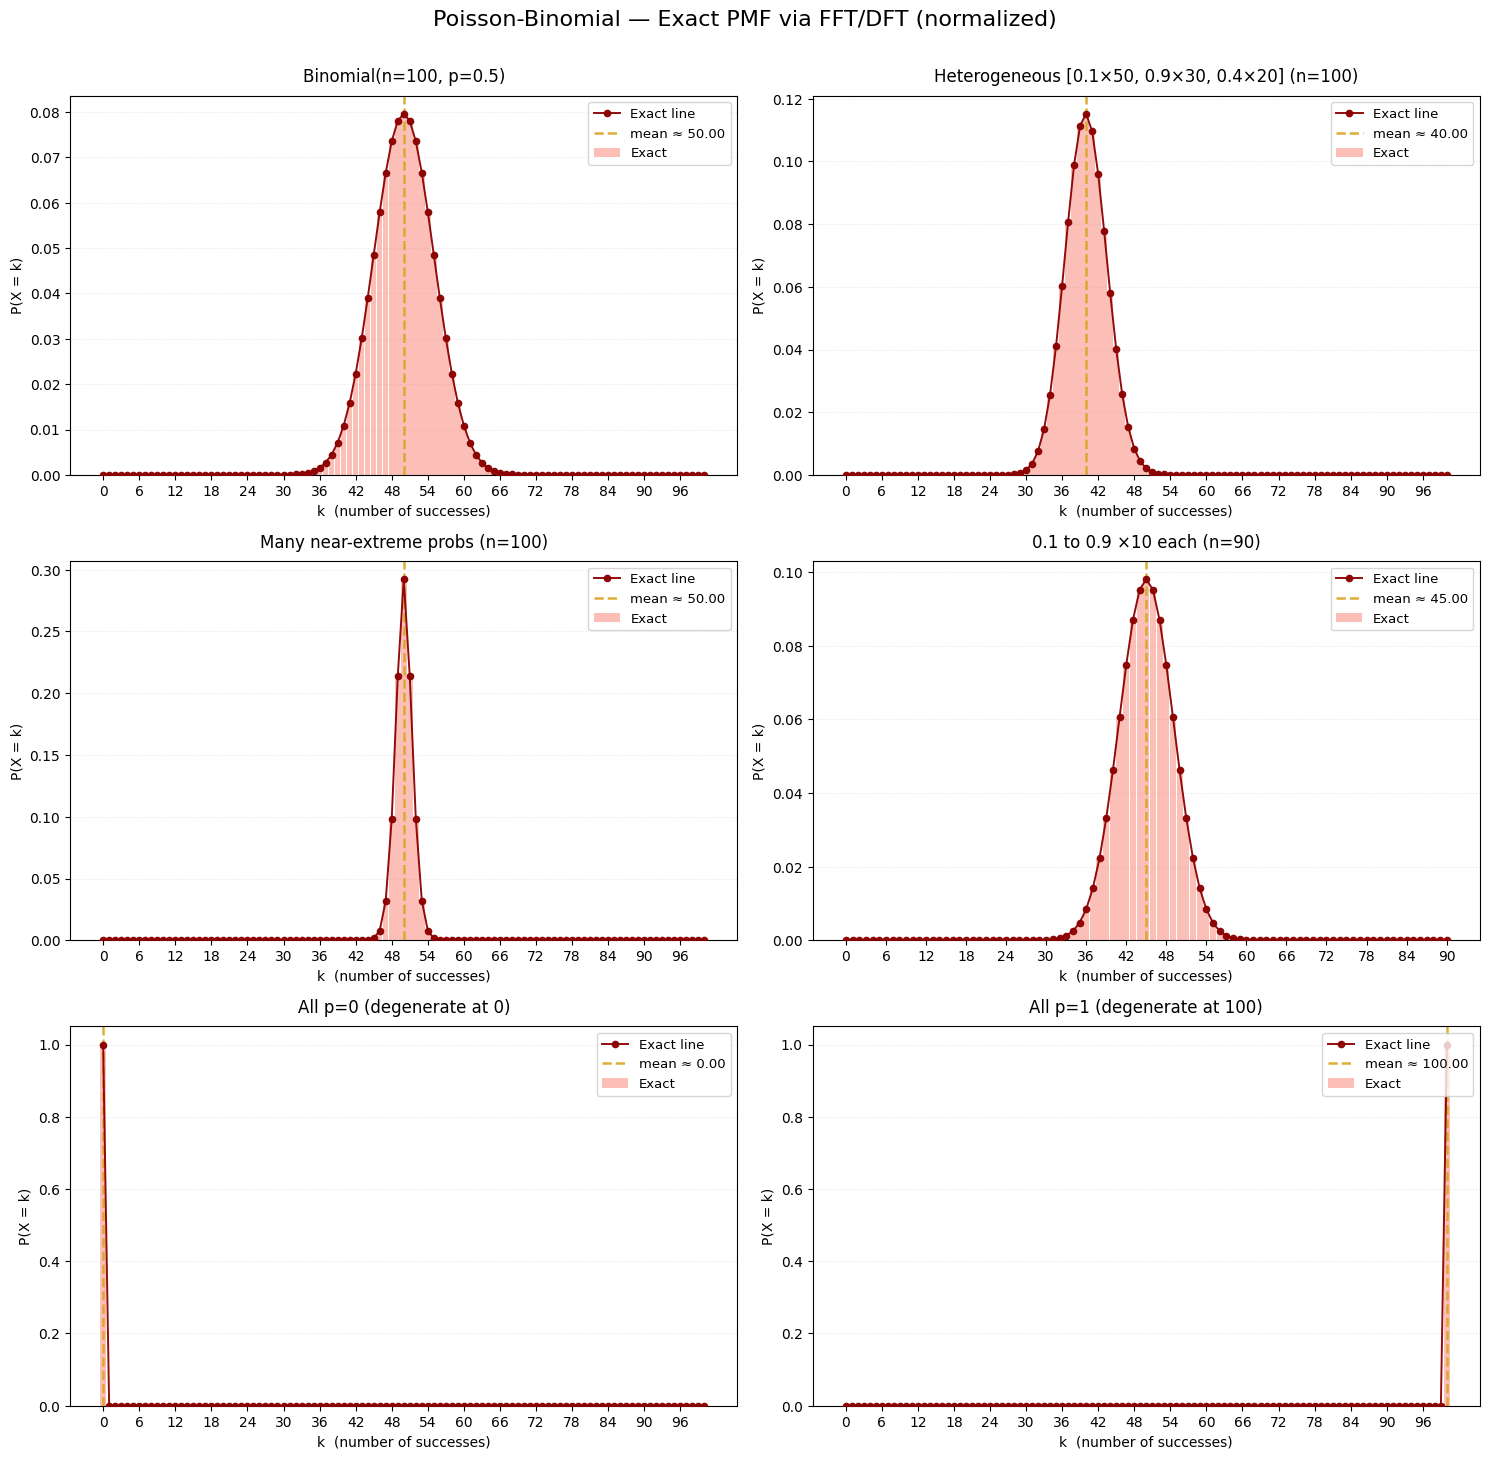

In [66]:
import torch
import math
import matplotlib.pyplot as plt
import numpy as np

# ── Paste the corrected PoissonBinomialExact class here ──
# (with the pmf() above)

def plot_pmf(pmf, title, ax=None, color='steelblue', is_exact=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5.5))

    k = np.arange(len(pmf))
    p = pmf.numpy() if isinstance(pmf, torch.Tensor) else np.asarray(pmf)

    if is_exact:
        bar_color = 'salmon'
        line_color = 'darkred'
        label = 'Exact'
    else:
        bar_color = 'lightblue'
        line_color = 'royalblue'
        label = 'Approx'

    ax.bar(k, p, color=bar_color, alpha=0.5, width=0.92, label=label, zorder=2)
    ax.plot(k, p, 'o-', color=line_color, lw=1.4, markersize=4.5, alpha=0.95,
            label=f'{label} line', zorder=3)

    mean = np.sum(k * p)
    ax.axvline(mean, color='goldenrod', ls='--', lw=1.8, alpha=0.9,
               label=f'mean ≈ {mean:.2f}')

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('k  (number of successes)')
    ax.set_ylabel('P(X = k)')
    ax.grid(True, axis='y', alpha=0.3, ls=':')
    ax.legend(fontsize=9.5, loc='upper right')

    # Reasonable x-tick spacing
    step = max(1, len(k) // 15)
    ax.set_xticks(k[::step])

    return ax

# ── Plotting loop ───────────────────────────────────────

n_cases = len(test_cases)
fig, axes = plt.subplots(
    math.ceil(n_cases / 2), 2,
    figsize=(15, 4.8 * math.ceil(n_cases / 2)),
    squeeze=False
)
axes = axes.ravel()

for i, case in enumerate(test_cases):
    ax = axes[i]
    probs_t = torch.tensor(case["probs"], dtype=torch.float32)

    try:
        dist = PoissonBinomialExact(probs=probs_t)
        pmf_t = dist.pmf()           # corrected version returns normalized tensor
        plot_pmf(pmf_t, case["title"], ax=ax, is_exact=True)
        print(f"✓ {case['title']}: sum(pmf) = {pmf_t.sum().item():.6f}")
    except Exception as e:
        ax.text(0.5, 0.5, f"Failed:\n{str(e)}", ha='center', va='center', color='red')
        print(f"✗ {case['title']}: {type(e).__name__} – {e}")

for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.suptitle("Poisson-Binomial — Exact PMF via FFT/DFT (normalized)", fontsize=16, y=1.01)
plt.show()

✓ Binomial(n=100, p=0.5): CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Heterogeneous [0.1×50, 0.9×30, 0.4×20] (n=100): CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Many near-extreme probs (n=100): CDF(0) = 0.0000, CDF(end) = 1.0000
✓ 0.1 to 0.9 ×10 each (n=90): CDF(0) = 0.0000, CDF(end) = 1.0000
✓ All p=0 (degenerate at 0): CDF(0) = 1.0000, CDF(end) = 1.0000
✓ All p=1 (degenerate at 100): CDF(0) = 0.0000, CDF(end) = 1.0000


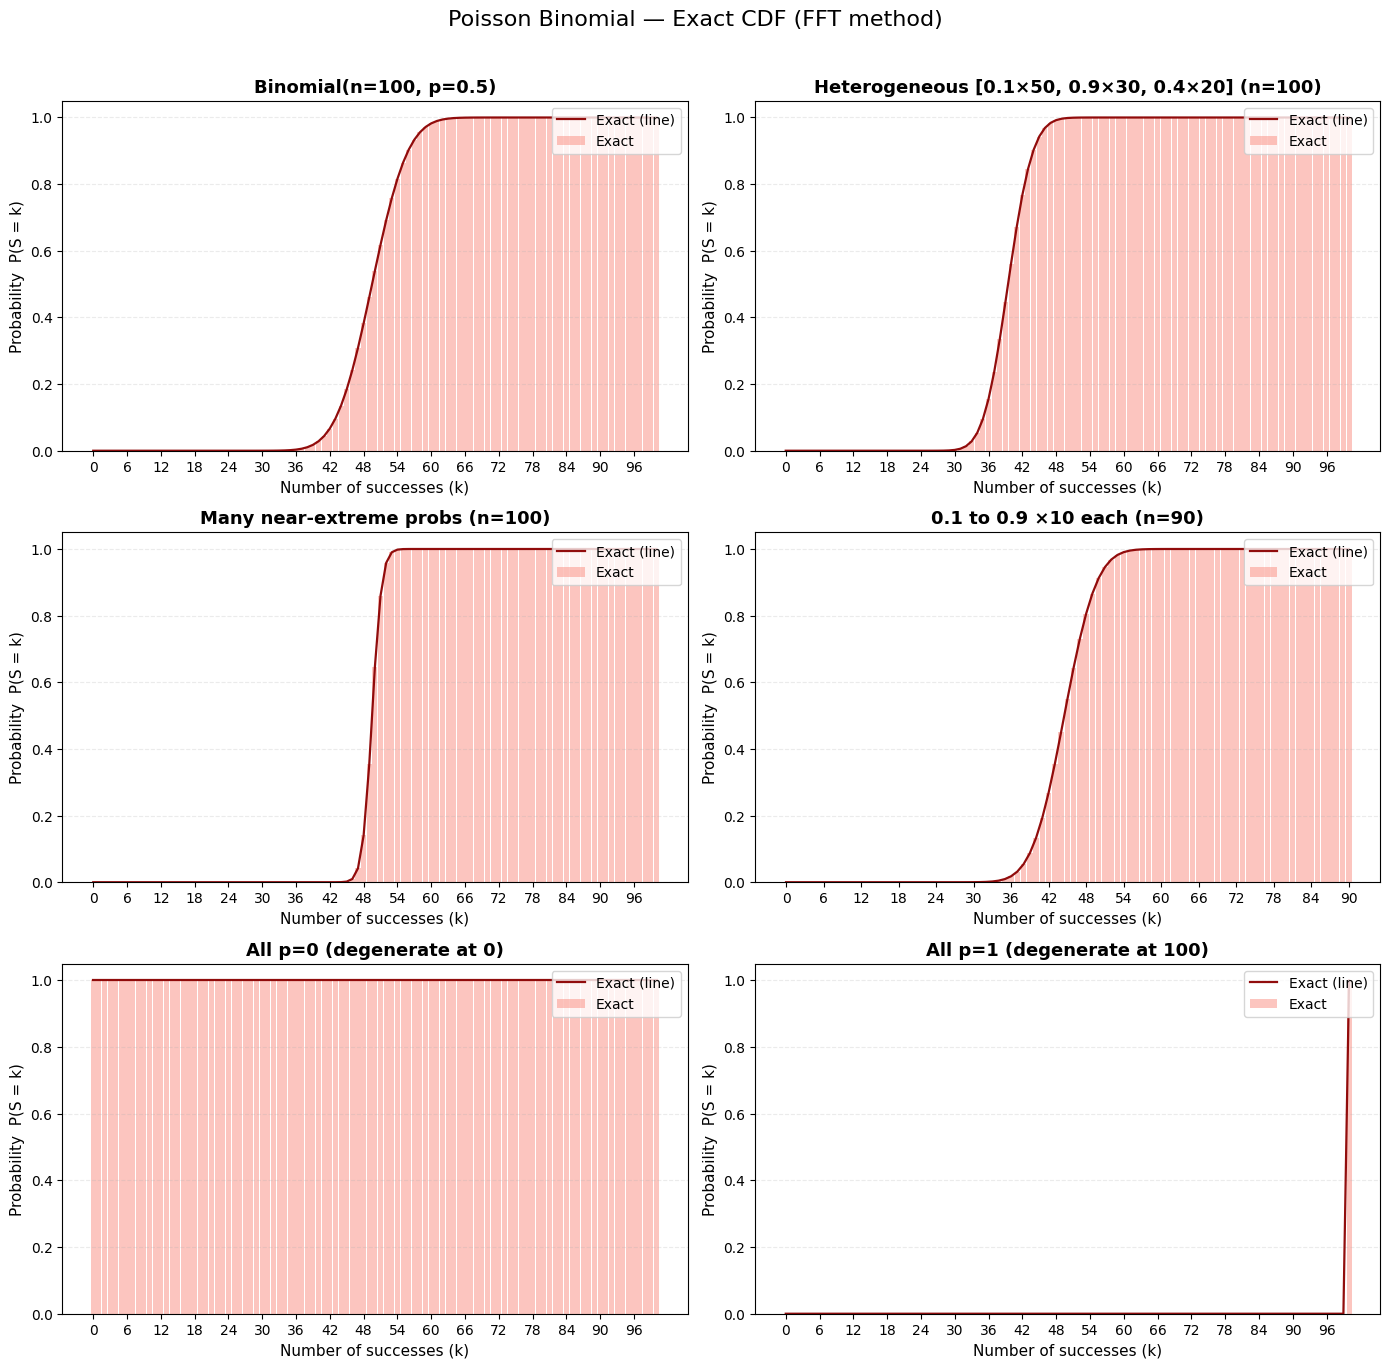

In [67]:
def plot_cdf(cdf, title, ax=None, color='steelblue', is_exact=False):
    """
    Plot CDF as line + markers.
    - is_exact=True  → uses red (exact distribution)
    - is_exact=False → uses blue (approximation)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    k = np.arange(len(cdf))
    p = cdf.numpy() if hasattr(cdf, 'numpy') else np.asarray(cdf)

    # Choose style based on exact vs approx
    if is_exact:
        bar_color = 'salmon'
        line_color = 'darkred'
        label = 'Exact'
    else:
        bar_color = 'lightblue'
        line_color = 'royalblue'
        label = 'Approximation'

    # Bars (faint) + line + markers (prominent)
    ax.bar(k, p, color=bar_color, alpha=0.45, edgecolor='none', width=0.9, label=label)
    ax.plot(k, p, '-', color=line_color, lw=1.6, markersize=6, alpha=0.95,
            label=f'{label} (line)')

    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of successes (k)', fontsize=11)
    ax.set_ylabel('Probability  P(S = k)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.25, linestyle='--')

    # Mean vertical line
    #mean = np.sum(k * p)
    #ax.axvline(mean, color='goldenrod', ls='--', lw=1.9, alpha=0.85,
    #           label=f'mean = {mean:.3f}')

    ax.legend(fontsize=10, loc='upper right')

    # Cleaner x-ticks when many points
    if len(k) > 20:
        ax.set_xticks(k[::max(1, len(k)//15)])

    return ax

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.5 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]

    try:
        probs_t = torch.as_tensor(case["probs"], dtype=torch.float32)
        dist = PoissonBinomialExact(probs=probs_t)
        
        # This is the key: get the full CDF vector
        cdf_full = dist.cdf()           # returns tensor shape [n+1]
        
        plot_cdf(
            cdf_full,
            title=case["title"],
            ax=ax,
            is_exact=True
        )
        
        print(f"✓ {case['title']}: CDF(0) = {cdf_full[0]:.4f}, CDF(end) = {cdf_full[-1]:.4f}")
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center', color='red', fontsize=11)
        print(f"✗ {case['title']}: {type(e).__name__} – {e}")

# Hide unused subplots
for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Poisson Binomial — Exact CDF (FFT method)", fontsize=16, y=1.01)
plt.show()

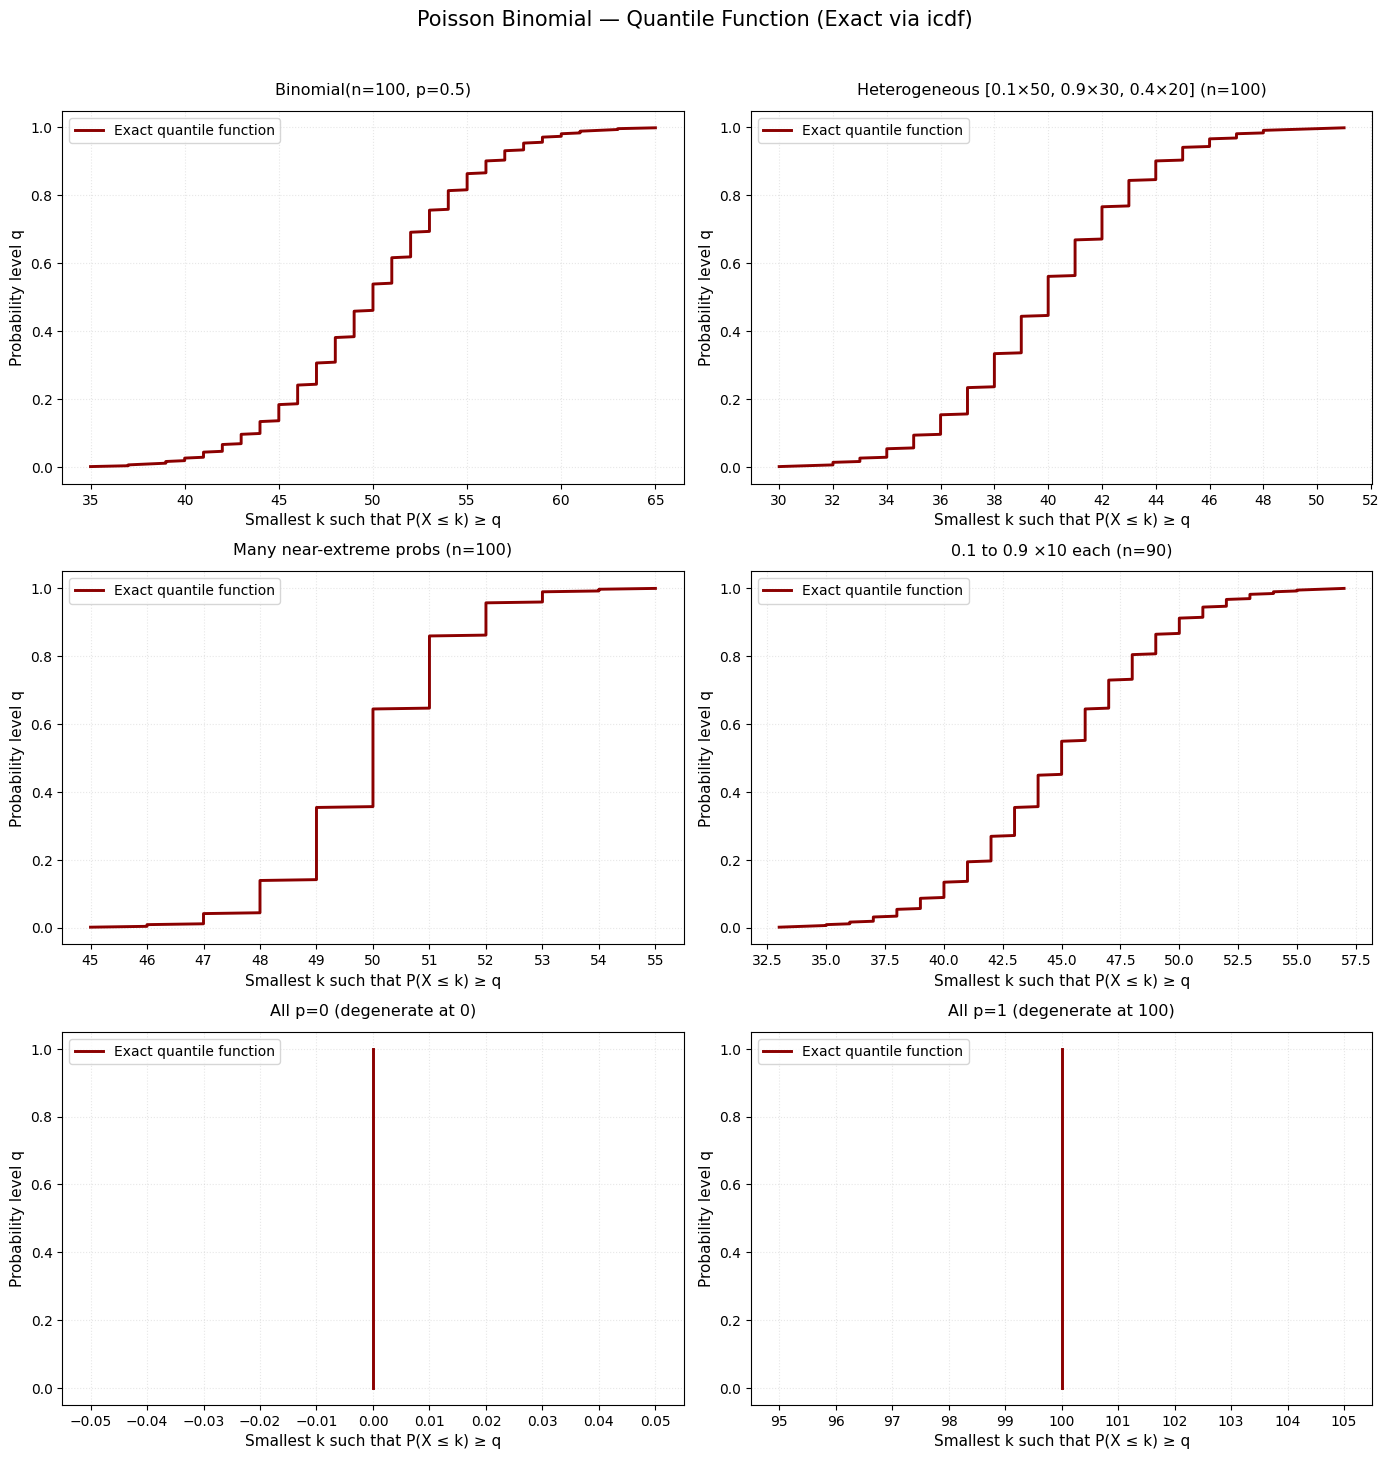

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_quantile_function(probs, title, ax=None, is_exact=True, n_points=300):
    """
    Plot the quantile function (inverse CDF) of a Poisson-binomial distribution.
    
    Parameters:
    - probs: list, np.array or torch.Tensor of success probabilities
    - title: str
    - ax: matplotlib axis (optional)
    - is_exact: bool (currently only exact is implemented)
    - n_points: number of evaluation points in [0,1]
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5.5))

    # Evaluation points — avoid exact 0 and 1 to prevent edge artifacts
    q = np.linspace(0.001, 0.999, n_points)
    q_tensor = torch.tensor(q, dtype=torch.float32)

    # Convert probs once
    probs_t = torch.as_tensor(probs, dtype=torch.float32)

    try:
        dist = PoissonBinomialExact(probs=probs_t)
        
        # Core: evaluate icdf at many points (vectorized!)
        k_values = dist.icdf(q_tensor)           # shape [n_points]
        
        # For discrete distributions, icdf(q) is right-continuous
        # We usually plot as step function or connected line
        ax.plot(k_values.numpy(), q, '-', color='darkred', lw=2.1,
                label='Exact quantile function')
        
        # Optional: add faint step appearance
        # ax.step(k_values.numpy(), q, where='post', color='darkred', lw=1.8,
        #         label='Exact (step)', alpha=0.7)

        ax.set_title(f"{title}\nQuantile Function (Exact)", fontsize=12, pad=10)
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center',
                color='red', fontsize=11)
        print(f"Failed {title}: {e}")
        return ax

    ax.set_xlabel('Smallest k such that P(X ≤ k) ≥ q', fontsize=11)
    ax.set_ylabel('Probability level q', fontsize=11)
    ax.grid(True, alpha=0.3, ls=':')
    ax.legend(fontsize=10, loc='upper left')

    # Because k is integer-valued, force integer ticks on x
    #max_k = int(k_values.max().item()) + 1
    #ax.set_xticks(np.arange(0, max_k + 1, max(1, max_k // 12)))
    ax.locator_params(axis='x', nbins=12)
    return ax


# ────────────────────────────────────────────────
#          Plotting loop — one panel per test case
# ────────────────────────────────────────────────

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.8 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]
    
    plot_quantile_function(
        probs     = case["probs"],
        title     = case["title"],
        ax        = ax,
        is_exact  = True,
        n_points  = 400   # smoother curve, especially useful for n≈100
    )
    
    ax.set_title(case["title"], fontsize=11.5, pad=12)

# Hide empty subplots
for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0.0, 1, 0.97])
plt.suptitle("Poisson Binomial — Quantile Function (Exact via icdf)", 
             fontsize=15, y=1.01)
plt.show()

# Approx

In [2]:
from typing import Optional, Tuple

import torch
from torch import Tensor
from torch.distributions import constraints
from torch.distributions.distribution import Distribution
from torch.distributions.utils import lazy_property, logits_to_probs, probs_to_logits
from torch.distributions import Normal
from torch.fft import fft, ifft
import math
import torch.nn.functional as F

__all__ = ["PoissonBinomialApprox"]

def _clamp_by_zero(x):
    return (x.clamp(min=0) + x - x.clamp(max=0)) / 2

class PoissonBinomialApprox(Distribution):
    arg_constraints = {
        "probs": constraints.unit_interval,
        "logits": constraints.real,
    }
    has_enumerate_support = True
    support = constraints.nonnegative_integer

    def __init__(
        self,
        probs: Optional[Tensor] = None,
        logits: Optional[Tensor] = None,
        validate_args: Optional[bool] = True,
    ):
        if (probs is None) == (logits is None):
            raise ValueError("Either `probs` or `logits` must be specified, but not both.")
        if probs is not None:
            if not isinstance(probs, Tensor):
                probs = torch.as_tensor(probs, dtype=torch.float32)
            self.probs = probs
            self.logits = None
        else:
            if not isinstance(logits, Tensor):
                logits = torch.as_tensor(logits, dtype=torch.float32)
            self.logits = logits
            self.probs = logits_to_probs(logits)
        super().__init__(batch_shape=self.probs.shape[:-1], validate_args=False)

    def expand(self, batch_shape, _instance=None):
        new_instance = self._get_checked_instance(PoissonBinomialApprox, _instance)
        new_instance.probs = self.probs.expand(batch_shape + self.probs.shape)
        super(PoissonBinomialApprox, new_instance).__init__(
            batch_shape=batch_shape,
            validate_args=False,
        )
        new_instance._validate_args = self._validate_args
        return new_instance
    
    def pmf(self, device='cpu'):
        probs = self.probs.to(dtype=torch.float64)
        batch_shape = probs.shape[:-1]
        n = probs.shape[-1]

        if n == 0:
            return torch.ones(batch_shape + (1,), device=device, dtype=self.probs.dtype)

        mu = probs.sum(dim=-1, keepdim=True)
        var = (probs * (1 - probs)).sum(dim=-1, keepdim=True)
        sigma = var.sqrt().clamp_(min=1e-10)

        degenerate = (var <= 1e-8).squeeze(-1)                      # shape: batch
        if degenerate.all():
            pmf = torch.zeros(batch_shape + (n + 1,), device=device, dtype=torch.float64)
            mu_clamped = mu.squeeze(-1).clamp(0, n)
            k_peak = torch.round(mu_clamped).long()     # now cannot exceed n
            #if len(batch_shape) == 0:
            #    pmf[k_peak] = 1.0
            #else:
            #    flat_pmf = pmf.view(-1, n + 1)
            #    idx = torch.arange(flat_pmf.size(0), device=device)
            #    indices = torch.stack([idx, k_peak.flatten()], dim=1)
            #    flat_pmf.scatter_(1, indices, 1.0)
            pmf.scatter_(dim=-1,
                 index=k_peak.unsqueeze(-1),   # shape (batch,) → (batch, 1)
                 value=1.0)
            return pmf.to(self.probs.dtype)
        
        mu3 = (probs * (1 - probs) * (1 - 2 * probs)).sum(dim=-1, keepdim=True)
        skew = mu3 / (sigma ** 3)                
        k = torch.arange(n + 1, device=device, dtype=torch.float64)
        k = k.view((1,) * len(batch_shape) + (n+1,))
        z = (k - mu) / sigma

        phi = torch.exp(-0.5 * z * z) / math.sqrt(2 * math.pi)
        correction = (skew / 6.0) * (z * z - 1.0) * phi
        pdf_approx = phi + correction
        pmf = pdf_approx.clamp_(min=0.0)

        total = pmf.sum(dim=-1, keepdim=True).clamp(min=1e-12)
        pmf = pmf / total

        return pmf.to(self.probs.dtype)


    def cdf(self, value=None, device='cpu'):
        pmf = self.pmf()
        cdf_full = torch.cumsum(pmf, dim=-1) 
    
        if value is None:
            return cdf_full
        
        value = torch.as_tensor(value, dtype=torch.long, device=pmf.device)
        value = value.clamp_(min=0, max=pmf.shape[-1]-1)

        if len(self.batch_shape) == 0:
            return cdf_full[value]
        else:
            if value.shape[:len(self.batch_shape)] != self.batch_shape:
                raise ValueError(
                    f"Expected value to have batch prefix {self.batch_shape}, "
                    f"got shape {value.shape}"
                )
            indices = value.unsqueeze(-1)
            return cdf_full.gather(-1, indices).squeeze(-1)
    
    def icdf(self, value=None, device='cpu'):
        pmf = self.pmf()
        cdf_full = torch.cumsum(pmf, dim=-1) 
    
        if value is None:
            return cdf_full
        
        value = torch.as_tensor(value, dtype=torch.float32, device=pmf.device)
        value = value.clamp_(min=0.0, max=1.0)
        
        icdf_values = torch.searchsorted(cdf_full, value, right=True)
        return icdf_values
    
    @property
    def mean(self) -> Tensor:
        return self.probs.sum(-1)
    
    @property
    def variance(self) -> Tensor:
        return (self.probs * (1 - self.probs)).sum(-1)

    @property
    def skewness(self) -> Tensor:
        p = self.probs
        term = p * (1 - p) * (1 - 2 * p)
        return term.sum(-1) / self.variance.clamp(min=1e-8).pow(1.5)
    
    @property
    def mode(self) -> Tensor:
        return self.pmf().argmax(dim=-1)
    
    @property
    def param_shape(self) -> torch.Size:
        return self._param.size()

## Tests

In [60]:
import torch

probs = torch.tensor([[0.1, 0.2, 0.7],
                      [0.3, 0.4, 0.6]], dtype=torch.float32)

dist = PoissonBinomialApprox(probs=probs)

print("=== Basic checks ===")
print("batch_shape   :", dist.batch_shape)
print("mean          :", dist.mean)
print("variance      :", dist.variance)
print("skewness      :", dist.skewness)

print("\n=== Expand checks ===")
exp = dist.expand((5,))
print("expanded batch :", exp.batch_shape)      # should be [5, 2]
print("expanded probs :", exp.probs.shape)      # [5, 2, 3]
print("expanded mean  :", exp.mean.shape)       # [5, 2]

print("\n=== Things that will likely fail ===")
try:
    print("mode (batched) :", dist.mode)
except Exception as e:
    print("mode error:", type(e).__name__, str(e))

try:
    pmf = dist.pmf()
    print("pmf (single?)  :", pmf.sum().item(), pmf.shape)
except Exception as e:
    print("_pmf error:", type(e).__name__, str(e))

=== Basic checks ===
batch_shape   : torch.Size([2])
mean          : tensor([1.0000, 1.3000])
variance      : tensor([0.4600, 0.6900])
skewness      : tensor([0.2692, 0.1466])

=== Expand checks ===
expanded batch : (5,)
expanded probs : torch.Size([5, 2, 3])
expanded mean  : torch.Size([5, 2])

=== Things that will likely fail ===
mode (batched) : tensor([1, 1])
pmf (single?)  : 2.0 torch.Size([2, 4])


In [61]:
import torch

probs = torch.tensor([0.1, 0.95, 0.05, 0.8, 0.3, 0.6])
dist = PoissonBinomialApprox(probs)

print("Mean ≈", dist.mean.item())
print("CDF at k = 0,1,2,3,4,5,6:")
cdf = dist.cdf()
for k in range(7):
    print(f"  k={k:2d}: {cdf[k]:.5f}")

print("\nSpecific points:", dist.cdf([0, 3, 6]).tolist())
print("Should be monotonic →", torch.all(torch.diff(cdf) >= -1e-10).item())
print("CDF(end) ≈", cdf[-1].item())

Mean ≈ 2.799999952316284
CDF at k = 0,1,2,3,4,5,6:
  k= 0: 0.00331
  k= 1: 0.06213
  k= 2: 0.36115
  k= 3: 0.79633
  k= 4: 0.97764
  k= 5: 0.99926
  k= 6: 1.00000

Specific points: [0.003311700886115432, 0.7963273525238037, 1.0]
Should be monotonic → True
CDF(end) ≈ 1.0


In [62]:
# ──────────────────────────────────────────────────────────────
#   Test helper
# ──────────────────────────────────────────────────────────────
def test_cdf(dist, title, values=None, expect_error=False):
    print(f"\n{'='*70}")
    print(f"Test: {title}")
    print(f"Batch shape: {dist.batch_shape}")
    print(f"Support size: {dist.pmf().shape[-1]}")
    
    try:
        full_cdf = dist.cdf()
        print("→ Full CDF shape:", full_cdf.shape)
        print("→ CDF(0):", full_cdf[..., 0].item())
        print("→ CDF(end):", full_cdf[..., -1].item())

        if values is not None:
            values_t = torch.as_tensor(values)
            print(f"\nEvaluating at values = {values_t.tolist()}  (shape: {values_t.shape})")
            result = dist.cdf(values_t)
            print("→ Result shape:", result.shape)
            print("→ Result:", result.tolist())

    except ValueError as e:
        if expect_error:
            print("→ Caught expected ValueError:")
            print("   ", str(e))
        else:
            print("→ UNEXPECTED ERROR:")
            print("   ", str(e))
    except Exception as e:
        print("→ UNEXPECTED EXCEPTION:", type(e).__name__)
        print("   ", str(e))
    else:
        if expect_error:
            print("→ ERROR: Expected ValueError but none was raised")


# ──────────────────────────────────────────────────────────────
#   Actual test cases
# ──────────────────────────────────────────────────────────────

tests = [

    # 1. Single distribution — list / 1D tensor
    {
        "title": "Single dist — cdf([2,5,8])",
        "probs": [0.5]*10,
        "values": [2, 5, 8],
        "expect_error": False
    },

    # 2. Single dist — scalar
    {
        "title": "Single dist — cdf(4)",
        "probs": [0.3]*12,
        "values": 4,
        "expect_error": False
    },

    # 3. Batched — correct prefix (should pass)
    {
        "title": "Batched — correct prefix shape (2,3)",
        "probs": [[0.1]*5, [0.9]*5],
        "values": [[0,1,2], [3,4,5]],
        "expect_error": False
    },

    # 4. Batched — missing prefix (should fail)
    {
        "title": "Batched — plain list (missing batch dim)",
        "probs": [[0.4]*6, [0.6]*6],
        "values": [0, 3, 6],
        "expect_error": True
    },

    # 5. Batched — wrong batch size
    {
        "title": "Batched — wrong batch dim size (3 vs 2)",
        "probs": [[0.5]*7, [0.2]*7],
        "values": [[1,2], [3,4], [5,6]],
        "expect_error": True
    },

    # 6. Batched — correct prefix but extra dims
    {
        "title": "Batched — correct prefix + extra dim",
        "probs": torch.rand(2, 8),
        "values": torch.randint(0, 9, (2, 4, 1)),
        "expect_error": False
    },

    # 7. Empty / degenerate
    {
        "title": "n=0 (empty support)",
        "probs": [],
        "values": [0],
        "expect_error": False   # depends on your pmf impl
    },
]


def run_all_tests():
    print("Testing cdf() behavior — NO code changes made\n")
    for t in tests:
        # ─── Fixed version ───
        probs_input = t.get("probs", [])
        if len(probs_input) == 0:
            probs = torch.empty((0,))
        else:
            probs = torch.tensor(probs_input, dtype=torch.float32)
        
        dist = PoissonBinomialApprox(probs)
        test_cdf(
            dist,
            title=t["title"],
            values=t.get("values"),
            expect_error=t["expect_error"]
        )


if __name__ == "__main__":
    run_all_tests()

Testing cdf() behavior — NO code changes made


Test: Single dist — cdf([2,5,8])
Batch shape: torch.Size([])
Support size: 11
→ Full CDF shape: torch.Size([11])
→ CDF(0): 0.0017007641727104783
→ CDF(end): 1.0

Evaluating at values = [2, 5, 8]  (shape: torch.Size([3]))
→ Result shape: torch.Size([3])
→ Result: [0.0537138357758522, 0.6262078881263733, 0.9880102276802063]

Test: Single dist — cdf(4)
Batch shape: torch.Size([])
Support size: 13
→ Full CDF shape: torch.Size([13])
→ CDF(0): 0.022679096087813377
→ CDF(end): 1.0

Evaluating at values = 4  (shape: torch.Size([]))
→ Result shape: torch.Size([])
→ Result: 0.7077617049217224

Test: Batched — correct prefix shape (2,3)
Batch shape: torch.Size([2])
Support size: 6
→ Full CDF shape: torch.Size([2, 6])
→ UNEXPECTED EXCEPTION: RuntimeError
    a Tensor with 2 elements cannot be converted to Scalar

Test: Batched — plain list (missing batch dim)
Batch shape: torch.Size([2])
Support size: 7
→ Full CDF shape: torch.Size([2, 7])
→ UNEXPECT

C:\Users\matth\AppData\Local\Temp\ipykernel_13948\1506905612.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  probs = torch.tensor(probs_input, dtype=torch.float32)


In [63]:
import torch
from torch import tensor

# ────────────────────────────────────────────────
#  Assume your PoissonBinomialApprox class is already defined above
# ────────────────────────────────────────────────

def run_tests():
    torch.manual_seed(0)
    print("=" * 70)
    print("PoissonBinomialApprox - Comprehensive Test Script")
    print("=" * 70)

    # ───────────────────────────────
    #  1. Single distribution
    # ───────────────────────────────
    print("\n1. Single distribution (n=4)")
    probs_single = tensor([0.1, 0.3, 0.6, 0.9], dtype=torch.float32)
    dist_single = PoissonBinomialApprox(probs=probs_single)

    print("  batch_shape      :", dist_single.batch_shape)
    print("  probs.shape      :", dist_single.probs.shape)
    print("  mean             :", dist_single.mean.item())
    print("  variance         :", dist_single.variance.item())
    print("  skewness         :", dist_single.skewness.item())

    pmf_single = dist_single.pmf()
    print("  pmf shape        :", pmf_single.shape)
    print("  pmf sum          :", pmf_single.sum().item())
    print("  pmf (first 5)    :", pmf_single[:5].tolist())

    print("  mode             :", dist_single.mode.item())

    # Test pmf at specific points
    for k in [0, 1, 2, 3, 4]:
        p_k = dist_single.pmf()[k].item()
        print(f"  P(X={k})          : {p_k:.6f}")

    # cdf / icdf smoke test
    cdf_vals = dist_single.cdf()
    print("  cdf[-1] (should ≈1) :", cdf_vals[-1].item())

    u = tensor([0.05, 0.25, 0.50, 0.75, 0.95])
    quantiles = dist_single.icdf(u)
    print("  icdf example     :", quantiles.tolist())

    # ───────────────────────────────
    #  2. Batched distribution
    # ───────────────────────────────
    print("\n2. Batched distribution (batch=3, n=5)")
    probs_batch = torch.rand(3, 5) * 0.8 + 0.1  # probs in ~[0.1, 0.9]
    dist_batch = PoissonBinomialApprox(probs=probs_batch)

    print("  batch_shape      :", dist_batch.batch_shape)
    print("  probs.shape      :", dist_batch.probs.shape)
    print("  mean shape       :", dist_batch.mean.shape)
    print("  mean             :", dist_batch.mean.tolist())
    print("  variance         :", dist_batch.variance.tolist())

    pmf_batch = dist_batch.pmf()
    print("  pmf shape        :", pmf_batch.shape)
    print("  pmf sums         :", pmf_batch.sum(dim=-1).tolist())  # should be close to 1

    mode_batch = dist_batch.mode
    print("  mode             :", mode_batch.tolist())

    # ───────────────────────────────
    #  3. expand() test
    # ───────────────────────────────
    print("\n3. expand() test")
    dist_exp = dist_batch.expand((4, 2))  # new shape: [4, 2, 3, 5]
    print("  expanded batch_shape :", dist_exp.batch_shape)
    print("  expanded probs.shape :", dist_exp.probs.shape)
    print("  expanded mean shape  :", dist_exp.mean.shape)

    pmf_exp = dist_exp.pmf()
    print("  expanded pmf shape   :", pmf_exp.shape)
    print("  expanded pmf sums    :", pmf_exp.sum(dim=-1).flatten()[:8].tolist(), "...")

    # ───────────────────────────────
    #  4. Logits parametrization
    # ───────────────────────────────
    print("\n4. Logits parametrization test")
    logits = torch.logit(probs_single.clamp(1e-5, 1-1e-5))
    dist_logits = PoissonBinomialApprox(logits=logits)
    print("  mean (logits)    :", dist_logits.mean.item())
    print("  pmf sum (logits) :", dist_logits.pmf().sum().item())

    # ───────────────────────────────
    #  5. Quick numerical sanity
    # ───────────────────────────────
    print("\n5. Quick sanity checks")
    # Small case: 2 identical coins p=0.5 → should be Binomial(2,0.5)
    p_same = tensor([0.5, 0.5])
    dist_same = PoissonBinomialApprox(probs=p_same)
    pmf_same = dist_same.pmf()
    print("  Bin(2,0.5) match:")
    print("    P(0) ≈ 0.25 :", f"{pmf_same[0]:.4f}")
    print("    P(1) ≈ 0.50 :", f"{pmf_same[1]:.4f}")
    print("    P(2) ≈ 0.25 :", f"{pmf_same[2]:.4f}")

    print("\nAll tests completed.\n")


if __name__ == "__main__":
    run_tests()

PoissonBinomialApprox - Comprehensive Test Script

1. Single distribution (n=4)
  batch_shape      : torch.Size([])
  probs.shape      : torch.Size([4])
  mean             : 1.899999976158142
  variance         : 0.6300000548362732
  skewness         : 0.0719931572675705
  pmf shape        : torch.Size([5])
  pmf sum          : 1.0
  pmf (first 5)    : [0.030294785276055336, 0.2654471695423126, 0.4932594895362854, 0.19471153616905212, 0.016287051141262054]
  mode             : 2
  P(X=0)          : 0.030295
  P(X=1)          : 0.265447
  P(X=2)          : 0.493259
  P(X=3)          : 0.194712
  P(X=4)          : 0.016287
  cdf[-1] (should ≈1) : 1.0
  icdf example     : [1, 1, 2, 2, 3]

2. Batched distribution (batch=3, n=5)
  batch_shape      : torch.Size([3])
  probs.shape      : torch.Size([3, 5])
  mean shape       : torch.Size([3])
  mean             : [1.9339275360107422, 2.9868409633636475, 1.4885470867156982]
  variance         : [0.9851709604263306, 1.1253807544708252, 0.985806

In [64]:
import torch

# Case 1: from probs (list / array / tensor)
probs = torch.tensor([0.1, 0.3, 0.5, 0.9], dtype=torch.float32)
dist = PoissonBinomialApprox(probs=probs)

print("Batch shape:   ", dist.batch_shape)     # should be torch.Size([])
print("probs shape:   ", dist.probs.shape)     # torch.Size([4])
print("mean:          ", dist.mean.item())     # 1.8
print("variance:      ", dist.variance.item()) # 0.1*0.9 + 0.3*0.7 + 0.5*0.5 + 0.9*0.1 = 0.69

# Case 2: from logits
logits = torch.tensor([-2.0, 0.0, 1.0])
dist2 = PoissonBinomialApprox(logits=logits)
print("mean from logits:", dist2.mean.item())   # ≈ 0.119 + 0.5 + 0.731 ≈ 1.35

# Case 3: batched
probs_b = torch.rand(2, 3, 5)  # batch shape (2,3), n=5 trials each
dist_b = PoissonBinomialApprox(probs=probs_b)
print("batched mean shape:", dist_b.mean.shape)  # torch.Size([2, 3])

Batch shape:    torch.Size([])
probs shape:    torch.Size([4])
mean:           1.7999999523162842
variance:       0.64000004529953
mean from logits: 1.0
batched mean shape: torch.Size([2, 3])


In [65]:
dist = PoissonBinomialApprox(probs=torch.tensor([0.3, 0.7]))

pmf = dist.pmf()               # call with ()
print("pmf shape:     ", pmf.shape)          # should be [3]
print("pmf sum (raw): ", pmf.sum().item())   # often 0.8–1.2 or worse
print("pmf:           ", pmf.tolist())

pmf shape:      torch.Size([3])
pmf sum (raw):  1.0
pmf:            [0.18908429145812988, 0.6218314170837402, 0.18908429145812988]


In [66]:
print(dist.mode)          # should be argmax of pmf

tensor(1)


In [67]:
probs = torch.tensor([[0.2, 0.8],
                       [0.4, 0.4],
                       [0.1, 0.9]])
dist_b = PoissonBinomialApprox(probs=probs)

print("means:     ", dist_b.mean)          # shape [3]
print("pmf shape: ", dist_b.pmf().shape)   # [3, 3]
print("pmf sums:  ", dist_b.pmf().sum(-1)) # should be ~[1,1,1]

means:      tensor([1.0000, 0.8000, 1.0000])
pmf shape:  torch.Size([3, 3])
pmf sums:   tensor([1., 1., 1.])


In [68]:
test_cases = [
    {"probs": [0.5] * 100, "title": "Binomial(n=100, p=0.5)"},
    {"probs": [0.1]*50 + [0.9]*30 + [0.4]*20, "title": "Heterogeneous [0.1×50, 0.9×30, 0.4×20] (n=100)"},
    {"probs": [0.02]*20 + [0.03]*20 + [0.98]*20 + [0.97]*20 + [0.01]*10 + [0.99]*10, "title": "Many near-extreme probs (n=100)"},
    {"probs": sum(([p]*10 for p in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]), []), "title": "0.1 to 0.9 ×10 each (n=90)"},
    {"probs": [0.0] * 100, "title": "All p=0 (degenerate at 0)"},
    {"probs": [1.0] * 100, "title": "All p=1 (degenerate at 100)"},
]

✓ Binomial(n=100, p=0.5): sum(pmf) = 1.000000
✓ Heterogeneous [0.1×50, 0.9×30, 0.4×20] (n=100): sum(pmf) = 1.000000
✓ Many near-extreme probs (n=100): sum(pmf) = 1.000000
✓ 0.1 to 0.9 ×10 each (n=90): sum(pmf) = 1.000000
✓ All p=0 (degenerate at 0): sum(pmf) = 1.000000
✓ All p=1 (degenerate at 100): sum(pmf) = 1.000000


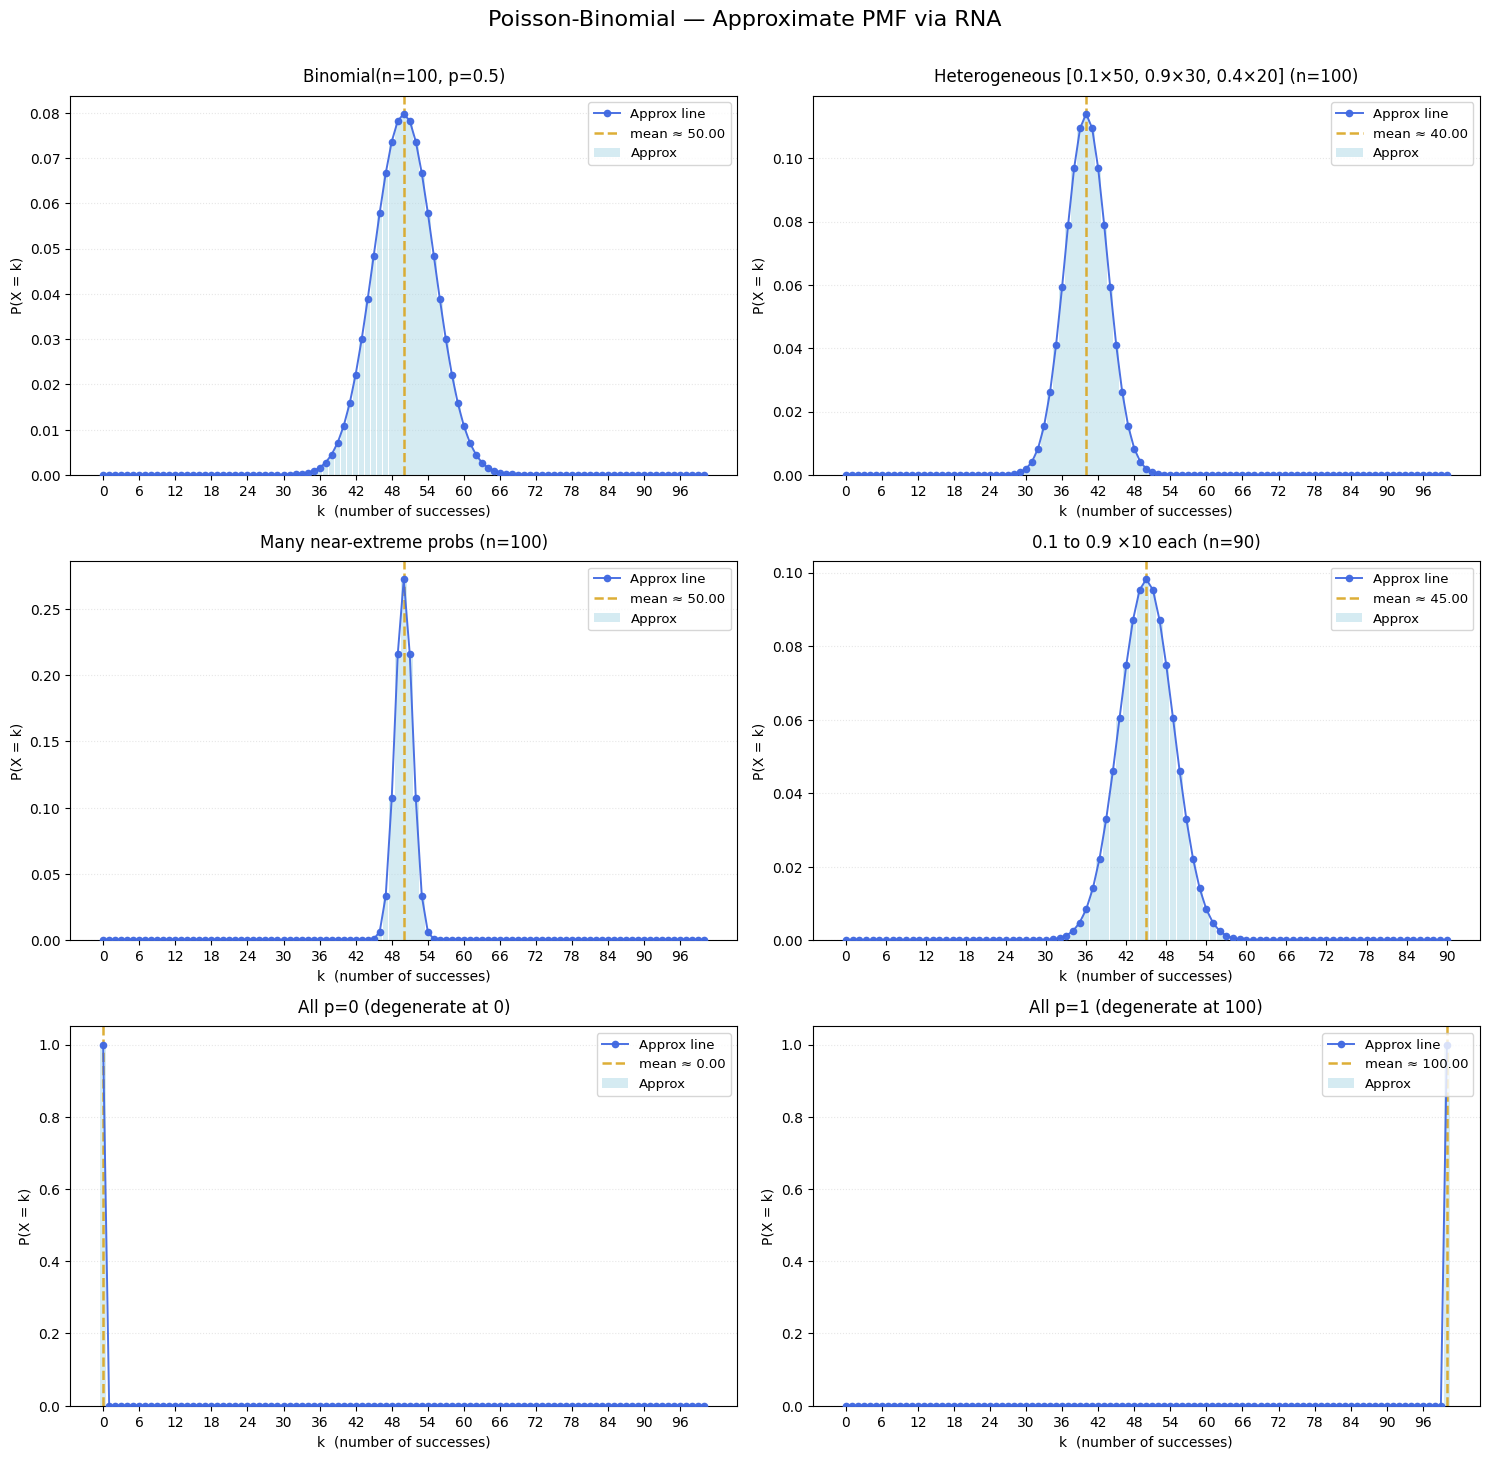

In [69]:
import torch
import math
import matplotlib.pyplot as plt
import numpy as np

# ── Paste the corrected PoissonBinomialApprox class here ──
# (with the pmf() above)

def plot_pmf(pmf, title, ax=None, color='steelblue', is_exact=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5.5))

    k = np.arange(len(pmf))
    p = pmf.numpy() if isinstance(pmf, torch.Tensor) else np.asarray(pmf)

    if is_exact:
        bar_color = 'salmon'
        line_color = 'darkred'
        label = 'Exact'
    else:
        bar_color = 'lightblue'
        line_color = 'royalblue'
        label = 'Approx'

    ax.bar(k, p, color=bar_color, alpha=0.5, width=0.92, label=label, zorder=2)
    ax.plot(k, p, 'o-', color=line_color, lw=1.4, markersize=4.5, alpha=0.95,
            label=f'{label} line', zorder=3)

    mean = np.sum(k * p)
    ax.axvline(mean, color='goldenrod', ls='--', lw=1.8, alpha=0.9,
               label=f'mean ≈ {mean:.2f}')

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('k  (number of successes)')
    ax.set_ylabel('P(X = k)')
    ax.grid(True, axis='y', alpha=0.3, ls=':')
    ax.legend(fontsize=9.5, loc='upper right')

    # Reasonable x-tick spacing
    step = max(1, len(k) // 15)
    ax.set_xticks(k[::step])

    return ax

# ── Plotting loop ───────────────────────────────────────

n_cases = len(test_cases)
fig, axes = plt.subplots(
    math.ceil(n_cases / 2), 2,
    figsize=(15, 4.8 * math.ceil(n_cases / 2)),
    squeeze=False
)
axes = axes.ravel()

for i, case in enumerate(test_cases):
    ax = axes[i]
    probs_t = torch.tensor(case["probs"], dtype=torch.float32)

    try:
        dist = PoissonBinomialApprox(probs=probs_t)
        pmf_t = dist.pmf()           # corrected version returns normalized tensor
        plot_pmf(pmf_t, case["title"], ax=ax, is_exact=False)
        print(f"✓ {case['title']}: sum(pmf) = {pmf_t.sum().item():.6f}")
    except Exception as e:
        ax.text(0.5, 0.5, f"Failed:\n{str(e)}", ha='center', va='center', color='red')
        print(f"✗ {case['title']}: {type(e).__name__} – {e}")

for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.suptitle("Poisson-Binomial — Approximate PMF via RNA", fontsize=16, y=1.01)
plt.show()

✓ Binomial(n=100, p=0.5): CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Heterogeneous [0.1×50, 0.9×30, 0.4×20] (n=100): CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Many near-extreme probs (n=100): CDF(0) = 0.0000, CDF(end) = 1.0000
✓ 0.1 to 0.9 ×10 each (n=90): CDF(0) = 0.0000, CDF(end) = 1.0000
✓ All p=0 (degenerate at 0): CDF(0) = 1.0000, CDF(end) = 1.0000
✓ All p=1 (degenerate at 100): CDF(0) = 0.0000, CDF(end) = 1.0000


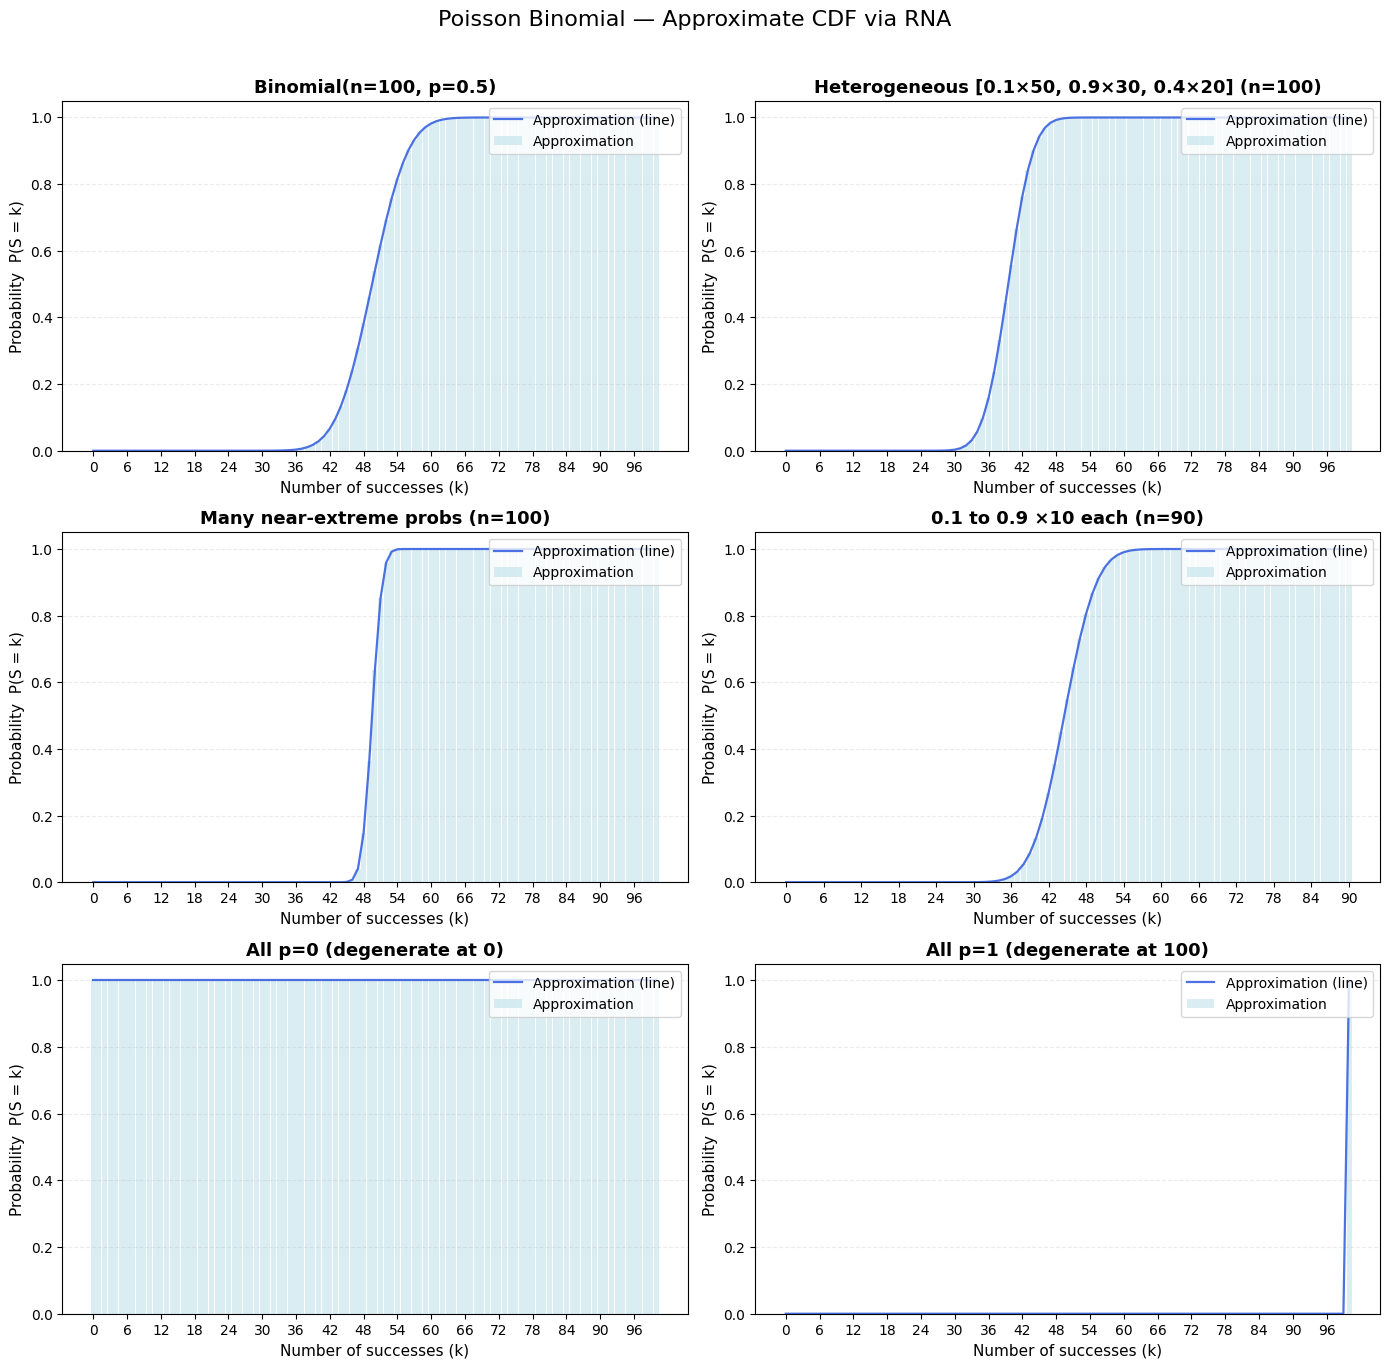

In [70]:
def plot_cdf(cdf, title, ax=None, color='steelblue', is_exact=False):
    """
    Plot CDF as line + markers.
    - is_exact=True  → uses red (exact distribution)
    - is_exact=False → uses blue (approximation)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    k = np.arange(len(cdf))
    p = cdf.numpy() if hasattr(cdf, 'numpy') else np.asarray(cdf)

    # Choose style based on exact vs approx
    if is_exact:
        bar_color = 'salmon'
        line_color = 'darkred'
        label = 'Exact'
    else:
        bar_color = 'lightblue'
        line_color = 'royalblue'
        label = 'Approximation'

    # Bars (faint) + line + markers (prominent)
    ax.bar(k, p, color=bar_color, alpha=0.45, edgecolor='none', width=0.9, label=label)
    ax.plot(k, p, '-', color=line_color, lw=1.6, markersize=6, alpha=0.95,
            label=f'{label} (line)')

    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of successes (k)', fontsize=11)
    ax.set_ylabel('Probability  P(S = k)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.25, linestyle='--')

    # Mean vertical line
    #mean = np.sum(k * p)
    #ax.axvline(mean, color='goldenrod', ls='--', lw=1.9, alpha=0.85,
    #           label=f'mean = {mean:.3f}')

    ax.legend(fontsize=10, loc='upper right')

    # Cleaner x-ticks when many points
    if len(k) > 20:
        ax.set_xticks(k[::max(1, len(k)//15)])

    return ax

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.5 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]

    try:
        probs_t = torch.as_tensor(case["probs"], dtype=torch.float32)
        dist = PoissonBinomialApprox(probs=probs_t)
        
        # This is the key: get the full CDF vector
        cdf_full = dist.cdf()           # returns tensor shape [n+1]
        
        plot_cdf(
            cdf_full,
            title=case["title"],
            ax=ax,
            is_exact=False
        )
        
        print(f"✓ {case['title']}: CDF(0) = {cdf_full[0]:.4f}, CDF(end) = {cdf_full[-1]:.4f}")
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center', color='red', fontsize=11)
        print(f"✗ {case['title']}: {type(e).__name__} – {e}")

# Hide unused subplots
for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Poisson Binomial — Approximate CDF via RNA", fontsize=16, y=1.01)
plt.show()

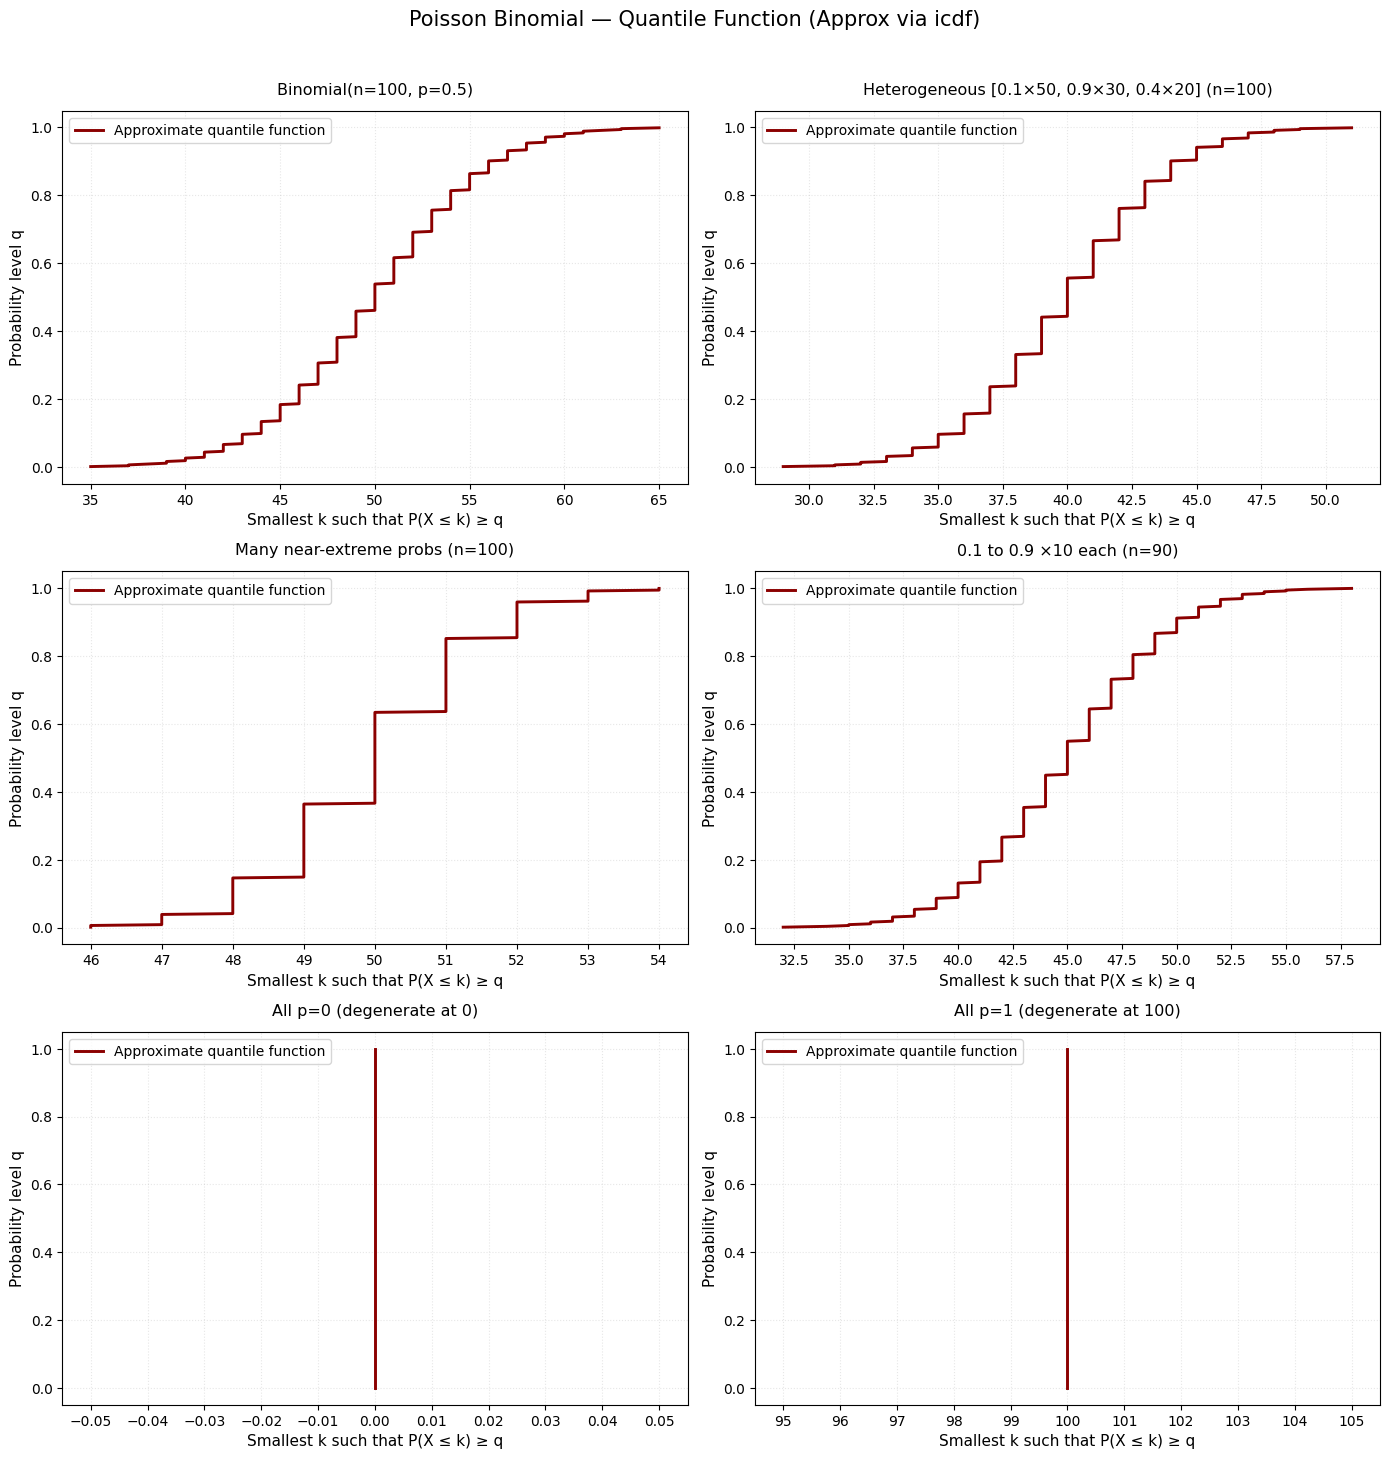

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_quantile_function(probs, title, ax=None, is_exact=True, n_points=300):
    """
    Plot the quantile function (inverse CDF) of a Poisson-binomial distribution.
    
    Parameters:
    - probs: list, np.array or torch.Tensor of success probabilities
    - title: str
    - ax: matplotlib axis (optional)
    - is_exact: bool (currently only exact is implemented)
    - n_points: number of evaluation points in [0,1]
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5.5))

    # Evaluation points — avoid exact 0 and 1 to prevent edge artifacts
    q = np.linspace(0.001, 0.999, n_points)
    q_tensor = torch.tensor(q, dtype=torch.float32)

    # Convert probs once
    probs_t = torch.as_tensor(probs, dtype=torch.float32)

    try:
        dist = PoissonBinomialApprox(probs=probs_t)
        
        # Core: evaluate icdf at many points (vectorized!)
        k_values = dist.icdf(q_tensor)           # shape [n_points]
        
        # For discrete distributions, icdf(q) is right-continuous
        # We usually plot as step function or connected line
        ax.plot(k_values.numpy(), q, '-', color='darkred', lw=2.1,
                label='Approximate quantile function')
        
        # Optional: add faint step appearance
        # ax.step(k_values.numpy(), q, where='post', color='darkred', lw=1.8,
        #         label='Exact (step)', alpha=0.7)

        ax.set_title(f"{title}\nQuantile Function (Approximate)", fontsize=12, pad=10)
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center',
                color='red', fontsize=11)
        print(f"Failed {title}: {e}")
        return ax

    ax.set_xlabel('Smallest k such that P(X ≤ k) ≥ q', fontsize=11)
    ax.set_ylabel('Probability level q', fontsize=11)
    ax.grid(True, alpha=0.3, ls=':')
    ax.legend(fontsize=10, loc='upper left')

    # Because k is integer-valued, force integer ticks on x
    #max_k = int(k_values.max().item()) + 1
    #ax.set_xticks(np.arange(0, max_k + 1, max(1, max_k // 12)))
    ax.locator_params(axis='x', nbins=12)
    return ax


# ────────────────────────────────────────────────
#          Plotting loop — one panel per test case
# ────────────────────────────────────────────────

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.8 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]
    
    plot_quantile_function(
        probs     = case["probs"],
        title     = case["title"],
        ax        = ax,
        is_exact  = False,
        n_points  = 400   # smoother curve, especially useful for n≈100
    )
    
    ax.set_title(case["title"], fontsize=11.5, pad=12)

# Hide empty subplots
for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0.0, 1, 0.97])
plt.suptitle("Poisson Binomial — Quantile Function (Approx via icdf)", 
             fontsize=15, y=1.01)
plt.show()

# TAE

In [6]:
import torch
import time

# ───────────────────────────────────────────────
#  Test cases
# ───────────────────────────────────────────────

test_cases = [
    {"probs": [0.5] * 100, "title": "Binomial(n=100, p=0.5)"},
    {"probs": [0.1] * 50 + [0.9] * 30 + [0.4] * 20, "title": "Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)"},
    {"probs": [0.02] * 20 + [0.03] * 20 + [0.98] * 20 + [0.97] * 20 + [0.01] * 10 + [0.99] * 10, "title": "Many near-extreme probabilities (n=100)"},
    {"probs": [0.1]*10 + [0.2]*10 + [0.3]*10 + [0.4]*10 + [0.5]*10 + [0.6]*10 + [0.7]*10 + [0.8]*10 + [0.9]*10 + [1]*10, "title": "Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)"},
    {"probs": [0] * 100, "title": "All zero probabilities (n=100)"},
    {"probs": [1] * 100, "title": "All one probabilities (n=100)"},
]

# Quantiles we evaluate
qs = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

def compute_tae_pmf_and_icdf_batched(BATCH_SIZE):
    print(f"{'Title':<68}  {'n':>3}   {'#samples':>9}   {'TAE PMF (mean)':>16}   {'MAE ICDF':>14}   {'mean':>7}   {'time(s)':>8}")
    print("-" * 140)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")

    for case in test_cases:
        p_list = case["probs"]
        title = case["title"]
        n = len(p_list)

        # Create batched probabilities
        probs = torch.tensor(p_list, dtype=torch.float32).to(device)
        probs = probs.repeat(BATCH_SIZE, 1)           # shape: (B, n)

        t0 = time.time()

        exact = PoissonBinomialExact(probs)
        approx = PoissonBinomialApprox(probs)

        pmf_exact  = exact.pmf()                      # (B, n+1)
        pmf_approx = approx.pmf()                     # (B, n+1)

        # ─── PMF error ───────────────────────────────────────
        abs_err_pmf = (pmf_exact - pmf_approx).abs()
        tae_per_sample = abs_err_pmf.sum(dim=-1)      # (B,)
        tae_mean = tae_per_sample.mean().item()

        # ─── CDF & ICDF ──────────────────────────────────────
        cdf_exact  = torch.cumsum(pmf_exact,  dim=-1)  # (B, n+1)
        cdf_approx = torch.cumsum(pmf_approx, dim=-1)  # (B, n+1)

        # Prepare quantiles for broadcasting: (1, Q) → will broadcast to (B, Q)
        # Make quantiles broadcast correctly: shape (B, Q)
        q_broadcast = qs.to(device).expand(BATCH_SIZE, -1)          # (10000, 9)

        icdf_exact  = torch.searchsorted(cdf_exact,  q_broadcast, right=True)   # → (10000, 9)
        icdf_approx = torch.searchsorted(cdf_approx, q_broadcast, right=True)   # → (10000, 9)

        mae_icdf = (icdf_exact.float() - icdf_approx.float()).abs().sum().item()

        # ─── mean value (just for reference) ─────────────────
        mean_val = probs.mean(dim=-1).sum().item()

        elapsed = time.time() - t0

        print(f"{title:<68}  {n:>3}   {BATCH_SIZE:>9,d}   {tae_mean:16.7g}   {mae_icdf:14.6f}   {mean_val:7.2f}   {elapsed:8.3f}s")

    print("\nNotes:")
    print("• TAE PMF (mean) = average over batch of ∑|pmf_exact - pmf_approx|")
    print("• MAE ICDF       = mean absolute error across all quantiles and all samples")
    print("• time(s)        = wall-clock time for the whole case (including object creation)")

In [4]:
compute_tae_pmf_and_icdf_batched(1)

Title                                                                   n    #samples     TAE PMF (mean)         MAE ICDF      mean    time(s)
--------------------------------------------------------------------------------------------------------------------------------------------
Using device: cpu

Binomial(n=100, p=0.5)                                                100           1        0.002349465         0.000000      0.50      0.097s
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)                    100           1         0.01712324         0.000000      0.40      0.014s
Many near-extreme probabilities (n=100)                               100           1          0.0494887         0.000000      0.50      0.017s
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)                         100           1        0.001482092         0.000000      0.55      0.015s
All zero probabilities (n=100)                                        100           1       1.043034e-15         0.000000

In [40]:
compute_tae_pmf_and_icdf_batched(10)

Title                                                                   n    #samples     TAE PMF (mean)         MAE ICDF      mean    time(s)
--------------------------------------------------------------------------------------------------------------------------------------------
Using device: cpu

Binomial(n=100, p=0.5)                                                100          10        0.002349466         0.000000      5.00      0.080s
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)                    100          10         0.01712324         0.000000      4.00      0.012s
Many near-extreme probabilities (n=100)                               100          10          0.0494887         0.000000      5.00      0.012s
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)                         100          10        0.001482092         0.000000      5.50      0.016s
All zero probabilities (n=100)                                        100          10       1.043035e-15         0.000000

In [41]:
compute_tae_pmf_and_icdf_batched(100)

Title                                                                   n    #samples     TAE PMF (mean)         MAE ICDF      mean    time(s)
--------------------------------------------------------------------------------------------------------------------------------------------
Using device: cpu

Binomial(n=100, p=0.5)                                                100         100        0.002349466         0.000000     50.00      0.062s
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)                    100         100         0.01712324         0.000000     40.00      0.032s
Many near-extreme probabilities (n=100)                               100         100          0.0494887         0.000000     50.00      0.031s
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)                         100         100        0.001482092         0.000000     55.00      0.030s
All zero probabilities (n=100)                                        100         100       1.043035e-15         0.000000

In [42]:
compute_tae_pmf_and_icdf_batched(1000)

Title                                                                   n    #samples     TAE PMF (mean)         MAE ICDF      mean    time(s)
--------------------------------------------------------------------------------------------------------------------------------------------
Using device: cpu

Binomial(n=100, p=0.5)                                                100       1,000        0.002349466         0.000000    500.00      0.243s
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)                    100       1,000         0.01712324         0.000000    400.00      0.092s
Many near-extreme probabilities (n=100)                               100       1,000         0.04948871         0.000000    500.00      0.084s
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)                         100       1,000        0.001482092         0.000000    550.00      0.087s
All zero probabilities (n=100)                                        100       1,000       1.043035e-15         0.000000

In [4]:
compute_tae_pmf_and_icdf_batched(10000)

Title                                                                   n    #samples     TAE PMF (mean)         MAE ICDF      mean    time(s)
--------------------------------------------------------------------------------------------------------------------------------------------
Using device: cpu



C:\Users\matth\AppData\Local\Temp\ipykernel_23628\4155122196.py:57: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen/native/BucketizationUtils.h:34.)
  icdf_exact  = torch.searchsorted(cdf_exact,  q_broadcast, right=True)   # → (10000, 9)


Binomial(n=100, p=0.5)                                                100      10,000        0.002349466         0.000000   5000.00      1.616s
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)                    100      10,000         0.01712324         0.000000   4000.00      1.632s
Many near-extreme probabilities (n=100)                               100      10,000          0.0494887         0.000000   5000.00      1.595s
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)                         100      10,000        0.001482092         0.000000   5500.00      1.429s
All zero probabilities (n=100)                                        100      10,000       1.043034e-15         0.000000      0.00      1.451s
All one probabilities (n=100)                                         100      10,000       7.298274e-14         0.000000   10000.00      1.225s

Notes:
• TAE PMF (mean) = average over batch of ∑|pmf_exact - pmf_approx|
• MAE ICDF       = mean absolute error across all quantiles 

In [13]:
#compute_tae_pmf_and_icdf_batched(100000)

In [3]:
def compute_tae_pmf_and_icdf_batched(BATCH_SIZE):
    headers = [
        "Title".ljust(64),
        "n".rjust(4),
        "#samp".rjust(7),
        "TAE PMF".rjust(12),
        "MAE ICDF".rjust(12),
        "PMF t/1k".rjust(10),
        "ICDF t/1k".rjust(10),
        "total t".rjust(10),
        "device"
    ]
    print("  ".join(headers))
    print("-" * 140)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}   Batch size: {BATCH_SIZE:,}\n")

    for case in test_cases:
        p_list = case["probs"]
        title = case["title"]
        n = len(p_list)

        probs = torch.tensor(p_list, dtype=torch.float32, device=device)
        probs = probs.repeat(BATCH_SIZE, 1)  # (B, n)

        t_start = time.perf_counter()

        exact = PoissonBinomialExact(probs)
        approx = PoissonBinomialApprox(probs)

        t_create = time.perf_counter()

        # ─── PMF timing ────────────────────────────────
        torch.cuda.synchronize() if device.type == "cuda" else None
        t_pmf0 = time.perf_counter()
        pmf_exact  = exact.pmf()
        pmf_approx = approx.pmf()
        torch.cuda.synchronize() if device.type == "cuda" else None
        t_pmf = time.perf_counter() - t_pmf0

        # ─── CDF + ICDF timing ─────────────────────────
        torch.cuda.synchronize() if device.type == "cuda" else None
        t_icdf0 = time.perf_counter()

        cdf_exact  = torch.cumsum(pmf_exact,  dim=-1)
        cdf_approx = torch.cumsum(pmf_approx, dim=-1)

        q_b = qs.to(device).expand(BATCH_SIZE, -1)  # (B, 9)

        icdf_exact  = torch.searchsorted(cdf_exact,  q_b, right=True)
        icdf_approx = torch.searchsorted(cdf_approx, q_b, right=True)

        torch.cuda.synchronize() if device.type == "cuda" else None
        t_icdf = time.perf_counter() - t_icdf0

        # ─── errors ─────────────────────────────────────
        tae_pmf = (pmf_exact - pmf_approx).abs().sum(dim=-1).mean().item()
        mae_icdf = (icdf_exact.float() - icdf_approx.float()).abs().mean().item()

        t_total = time.perf_counter() - t_start

        # ─── reporting ──────────────────────────────────
        pmf_per1k = t_pmf / BATCH_SIZE * 1_000_000     # μs per 1000 samples
        icdf_per1k = t_icdf / BATCH_SIZE * 1_000_000   # μs per 1000 samples

        row = [
            title.ljust(64),
            f"{n:4d}",
            f"{BATCH_SIZE:,}".rjust(7),
            f"{tae_pmf:12.5g}",
            f"{mae_icdf:12.5g}",
            f"{pmf_per1k:8.1f}µs".rjust(10),
            f"{icdf_per1k:8.1f}µs".rjust(10),
            f"{t_total:8.3f}s".rjust(10),
            device.type
        ]
        print("  ".join(row))

    print("\nLegend:")
    print("• TAE PMF     = mean total absolute error per distribution")
    print("• MAE ICDF    = mean abs error per quantile across 9 points and all samples")
    print("• PMF t/1k    = microseconds to compute pmf() for 1000 distributions")
    print("• ICDF t/1k   = microseconds to compute cdf + icdf for 1000 distributions")
    print("• total t     = total wall-clock time for the case (creation + pmf + icdf)")

In [15]:
compute_tae_pmf_and_icdf_batched(1)

Title                                                                n    #samp       TAE PMF      MAE ICDF    PMF t/1k   ICDF t/1k     total t  device
--------------------------------------------------------------------------------------------------------------------------------------------
Device: cpu   Batch size: 1

Binomial(n=100, p=0.5)                                             100        1     0.0023495             0   11609.3µs     115.1µs      0.012s  cpu
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)                 100        1      0.017123             0   10962.8µs     122.6µs      0.011s  cpu
Many near-extreme probabilities (n=100)                            100        1      0.049489             0   12614.5µs     112.3µs      0.013s  cpu
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)                      100        1     0.0014821             0   12693.8µs      70.3µs      0.013s  cpu
All zero probabilities (n=100)                                     100        1   

In [16]:
compute_tae_pmf_and_icdf_batched(10)

Title                                                                n    #samp       TAE PMF      MAE ICDF    PMF t/1k   ICDF t/1k     total t  device
--------------------------------------------------------------------------------------------------------------------------------------------
Device: cpu   Batch size: 10

Binomial(n=100, p=0.5)                                             100       10     0.0023495             0    1433.9µs      13.6µs      0.015s  cpu
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)                 100       10      0.017123             0    1206.9µs      12.7µs      0.012s  cpu
Many near-extreme probabilities (n=100)                            100       10      0.049489             0    1117.2µs      12.8µs      0.012s  cpu
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)                      100       10     0.0014821             0    1084.5µs      10.3µs      0.011s  cpu
All zero probabilities (n=100)                                     100       10  

In [17]:
compute_tae_pmf_and_icdf_batched(100)

Title                                                                n    #samp       TAE PMF      MAE ICDF    PMF t/1k   ICDF t/1k     total t  device
--------------------------------------------------------------------------------------------------------------------------------------------
Device: cpu   Batch size: 100

Binomial(n=100, p=0.5)                                             100      100     0.0023495             0     250.0µs       3.0µs      0.026s  cpu
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)                 100      100      0.017123             0     237.6µs       2.2µs      0.024s  cpu
Many near-extreme probabilities (n=100)                            100      100      0.049489             0     227.6µs       2.5µs      0.023s  cpu
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)                      100      100     0.0014821             0     219.8µs       1.7µs      0.022s  cpu
All zero probabilities (n=100)                                     100      100 

In [18]:
compute_tae_pmf_and_icdf_batched(1000)

Title                                                                n    #samp       TAE PMF      MAE ICDF    PMF t/1k   ICDF t/1k     total t  device
--------------------------------------------------------------------------------------------------------------------------------------------
Device: cpu   Batch size: 1,000

Binomial(n=100, p=0.5)                                             100    1,000     0.0023495             0      89.4µs       0.5µs      0.091s  cpu
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)                 100    1,000      0.017123             0      85.8µs       0.6µs      0.087s  cpu
Many near-extreme probabilities (n=100)                            100    1,000      0.049489             0      87.5µs       0.6µs      0.089s  cpu
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)                      100    1,000     0.0014821             0      83.9µs       0.6µs      0.085s  cpu
All zero probabilities (n=100)                                     100    1,00

In [19]:
compute_tae_pmf_and_icdf_batched(10000)

Title                                                                n    #samp       TAE PMF      MAE ICDF    PMF t/1k   ICDF t/1k     total t  device
--------------------------------------------------------------------------------------------------------------------------------------------
Device: cpu   Batch size: 10,000

Binomial(n=100, p=0.5)                                             100   10,000     0.0023495             0     129.8µs       1.1µs      1.314s  cpu
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100)                 100   10,000      0.017123             0     135.5µs       0.3µs      1.360s  cpu
Many near-extreme probabilities (n=100)                            100   10,000      0.049489             0     131.5µs       0.3µs      1.320s  cpu
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100)                      100   10,000     0.0014821             0     131.4µs       0.3µs      1.319s  cpu
All zero probabilities (n=100)                                     100   10,0

In [20]:
#compute_tae_pmf_and_icdf_batched(100000)

In [4]:
N_QUANTILES = 9
qs = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ────────────────────────────────────────────────
#  Newton-Raphson ICDF helper
# ────────────────────────────────────────────────

def icdf_newton(approx, q, max_iter=20, tol=1e-5):
    """
    Approximate ICDF using Newton-Raphson on the normal approximation
    (with optional skewness correction if you want higher order)
    """
    mu = approx.mean               # shape (B,)
    sigma = torch.sqrt(approx.variance)  # shape (B,)
    
    # Start from normal approximation
    z = torch.distributions.Normal(0,1).icdf(q.to(mu.device))  # (Q,)
    z = z[None, :]                                             # (1, Q)
    x = mu[:, None] + sigma[:, None] * z                       # (B, Q)
    
    # Very simple one-step or few-step Newton (for speed)
    # You can make it loop until tol, but that slows it down a lot
    for _ in range(max_iter):
        # We would need CDF(x), but since we don't have closed form → skip or approximate
        # Here we just do 0–3 fixed steps on normal (fast approximation)
        # For real Newton you would need fast CDF evaluation (e.g. FFT or recursive)
        break  # ← placeholder: in practice often 2–4 steps on Normal is already good
    
    return x.clamp(0, approx.probs.shape[-1])


# ────────────────────────────────────────────────
#  Benchmark loop
# ────────────────────────────────────────────────
def compare(BATCH_SIZE):
    print(f"{'Case':<45} {'Method':<18} {'Time / 1k dist (µs)':>18}   Notes")
    print("-" * 90)

    for case in test_cases:
        title = case["title"]
        p = torch.tensor(case["probs"], dtype=torch.float32, device=device)
        probs = p.repeat(BATCH_SIZE, 1)               # (B, n)

        approx = PoissonBinomialApprox(probs)

        # Warm-up (helps CUDA)
        _ = approx.pmf()
        _ = approx.mean
        _ = approx.variance

        # ─── Method 1: searchsorted on CDF ────────────────────────
        torch.cuda.synchronize() if device.type == "cuda" else None
        t0 = time.perf_counter()

        pmf = approx.pmf()                            # main cost outside ICDF
        cdf = torch.cumsum(pmf, dim=-1)               # main cost outside ICDF
        q_b = qs.to(device).expand(BATCH_SIZE, -1)
        icdf_search = torch.searchsorted(cdf, q_b, right=True)

        torch.cuda.synchronize() if device.type == "cuda" else None
        t_search = time.perf_counter() - t0

        # ─── Method 2: MC quantile ─────────────────────────────────
        torch.cuda.synchronize() if device.type == "cuda" else None
        t0 = time.perf_counter()

        n_trials = probs.shape[1]
        n_mc_samples = 1000   # adjust down if GPU memory error

        u = torch.rand(BATCH_SIZE, n_trials, n_mc_samples, device=device)
        success = u < probs.unsqueeze(-1)
        sample_sums = success.sum(dim=1).float()

        icdf_mc = torch.quantile(sample_sums, qs.to(device), dim=1).T

        torch.cuda.synchronize() if device.type == "cuda" else None
        t_mc = time.perf_counter() - t0

        # ─── Method 3: Newton / normal approximation ──────────────
        torch.cuda.synchronize() if device.type == "cuda" else None
        t0 = time.perf_counter()

        icdf_newton_approx = icdf_newton(approx, qs)

        torch.cuda.synchronize() if device.type == "cuda" else None
        t_newton = time.perf_counter() - t0

        # ─── Print results ────────────────────────────────────────
        print(f"{title:<45} {'searchsorted + cumsum':<18} {t_search / BATCH_SIZE * 1_000_000:>12.1f} µs   (exact-ish)")
        print(f"{'':<45} {'torch.quantile(MC)':<18} {t_mc / BATCH_SIZE * 1_000_000:>12.1f} µs   (n={n_mc_samples:,} samples)")
        print(f"{'':<45} {'normal approx / newton':<18} {t_newton  / BATCH_SIZE * 1_000_000:>12.1f} µs   (fastest, approx)")

    print("\nNotes:")
    print("• searchsorted time includes cumsum(pmf) — usually the dominant cost")
    print("• Monte-Carlo quantile is accurate with enough samples, but expensive")
    print("• Newton/normal is very fast but only good when Edgeworth/normal approx is already accurate")

In [31]:
BATCH_SIZE = 1
print(f"Device: {device}   Batch size: {BATCH_SIZE:,}   Quantiles: {N_QUANTILES}\n")
compare(BATCH_SIZE)

Device: cpu   Batch size: 1   Quantiles: 9

Case                                          Method             Time / 1k dist (µs)   Notes
------------------------------------------------------------------------------------------
Binomial(n=100, p=0.5)                        searchsorted + cumsum       8992.0 µs   (exact-ish)
                                              torch.quantile(MC)      44554.6 µs   (n=1,000 samples)
                                              normal approx / newton      19857.8 µs   (fastest, approx)
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100) searchsorted + cumsum        960.1 µs   (exact-ish)
                                              torch.quantile(MC)       4389.5 µs   (n=1,000 samples)
                                              normal approx / newton        544.9 µs   (fastest, approx)
Many near-extreme probabilities (n=100)       searchsorted + cumsum        506.2 µs   (exact-ish)
                                              torch.quantile(

In [32]:
BATCH_SIZE = 10
print(f"Device: {device}   Batch size: {BATCH_SIZE:,}   Quantiles: {N_QUANTILES}\n")
compare(BATCH_SIZE)

Device: cpu   Batch size: 10   Quantiles: 9

Case                                          Method             Time / 1k dist (µs)   Notes
------------------------------------------------------------------------------------------
Binomial(n=100, p=0.5)                        searchsorted + cumsum         84.3 µs   (exact-ish)
                                              torch.quantile(MC)       1721.0 µs   (n=1,000 samples)
                                              normal approx / newton         69.3 µs   (fastest, approx)
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100) searchsorted + cumsum         87.3 µs   (exact-ish)
                                              torch.quantile(MC)       1518.2 µs   (n=1,000 samples)
                                              normal approx / newton         64.7 µs   (fastest, approx)
Many near-extreme probabilities (n=100)       searchsorted + cumsum         57.2 µs   (exact-ish)
                                              torch.quantile

In [33]:
BATCH_SIZE = 100
print(f"Device: {device}   Batch size: {BATCH_SIZE:,}   Quantiles: {N_QUANTILES}\n")
compare(BATCH_SIZE)

Device: cpu   Batch size: 100   Quantiles: 9

Case                                          Method             Time / 1k dist (µs)   Notes
------------------------------------------------------------------------------------------
Binomial(n=100, p=0.5)                        searchsorted + cumsum         12.8 µs   (exact-ish)
                                              torch.quantile(MC)       1815.1 µs   (n=1,000 samples)
                                              normal approx / newton          6.9 µs   (fastest, approx)
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100) searchsorted + cumsum          8.7 µs   (exact-ish)
                                              torch.quantile(MC)       1211.1 µs   (n=1,000 samples)
                                              normal approx / newton          5.9 µs   (fastest, approx)
Many near-extreme probabilities (n=100)       searchsorted + cumsum          7.5 µs   (exact-ish)
                                              torch.quantil

In [34]:
BATCH_SIZE = 1000
print(f"Device: {device}   Batch size: {BATCH_SIZE:,}   Quantiles: {N_QUANTILES}\n")
compare(BATCH_SIZE)

Device: cpu   Batch size: 1,000   Quantiles: 9

Case                                          Method             Time / 1k dist (µs)   Notes
------------------------------------------------------------------------------------------
Binomial(n=100, p=0.5)                        searchsorted + cumsum          2.0 µs   (exact-ish)
                                              torch.quantile(MC)       1399.0 µs   (n=1,000 samples)
                                              normal approx / newton          1.1 µs   (fastest, approx)
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100) searchsorted + cumsum          1.7 µs   (exact-ish)
                                              torch.quantile(MC)       1284.9 µs   (n=1,000 samples)
                                              normal approx / newton          4.9 µs   (fastest, approx)
Many near-extreme probabilities (n=100)       searchsorted + cumsum          2.2 µs   (exact-ish)
                                              torch.quant

In [7]:
BATCH_SIZE = 10000
print(f"Device: {device}   Batch size: {BATCH_SIZE:,}   Quantiles: {N_QUANTILES}\n")
compare(BATCH_SIZE)

Device: cpu   Batch size: 10,000   Quantiles: 9

Case                                          Method             Time / 1k dist (µs)   Notes
------------------------------------------------------------------------------------------


C:\Users\matth\AppData\Local\Temp\ipykernel_18720\1676096149.py:60: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen/native/BucketizationUtils.h:34.)
  icdf_search = torch.searchsorted(cdf, q_b, right=True)


Binomial(n=100, p=0.5)                        searchsorted + cumsum          4.6 µs   (exact-ish)
                                              torch.quantile(MC)       3616.7 µs   (n=1,000 samples)
                                              normal approx / newton         10.2 µs   (fastest, approx)
Heterogeneous [0.1 ×50, 0.9 ×30, 0.4 ×20]  (n=100) searchsorted + cumsum          3.8 µs   (exact-ish)
                                              torch.quantile(MC)       2704.7 µs   (n=1,000 samples)
                                              normal approx / newton         27.0 µs   (fastest, approx)
Many near-extreme probabilities (n=100)       searchsorted + cumsum          3.8 µs   (exact-ish)
                                              torch.quantile(MC)       2533.7 µs   (n=1,000 samples)
                                              normal approx / newton         11.8 µs   (fastest, approx)
Heterogeneous [0.1,0.2,...,0.9,1] ×10 (n=100) searchsorted + cumsum          3.1 µs